# Freight rate prediction · Cycle 1
## Understand the data before modeling

**Goal:** explore the supplied freight loads, visualize pricing patterns, and identify decisions needed before training a model.

A row is one shipment. The target is **`posted_rate`**, the recorded total price in dollars. A future model will estimate that amount as `predicted_rate`.

This notebook covers:
1. Files, column meanings, and available inputs.
2. Missing values, invalid weights, and unusual observations.
3. Price distributions and relationships with distance, equipment, weight, location, and time.
4. Differences between development data and the final prediction inputs.
5. Stability of the market and quote signals.
6. The 31-row December scenario and decisions for the next cycle.

**Scope:** exploratory analysis only. No model is trained, no predictions are generated, and no source CSV is changed. Final-set features are inspected descriptively; final target prices are unavailable.

**Run:** choose the **Python (spotter)** kernel and run all cells from top to bottom. The project README contains virtual-environment and Jupyter commands.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display, Markdown

SEED = 42
COLORS = {"Development": "#245A81", "Final inputs": "#D08B2E"}
EQUIPMENT_COLORS = {"Dry Van": "#245A81", "Reefer": "#438D7A", "Flatbed": "#D08B2E"}
sns.set_theme(style="whitegrid", context="notebook", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (11, 4.5),
    "figure.constrained_layout.use": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 18)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
dollars = FuncFormatter(lambda value, _: f"${value:,.0f}")

print(f"Python: {sys.version.split()[0]}")
print(f"Interpreter: {sys.executable}")
print(f"pandas {pd.__version__} | NumPy {np.__version__} | seaborn {sns.__version__}")

Python: 3.13.7
Interpreter: C:\Users\default.LAPTOP-H1OG6SJ2\Desktop\Projects\spotter\.venv\Scripts\python.exe
pandas 3.0.6 | NumPy 2.5.3 | seaborn 0.13.2


## 1. Load the files and identify their roles

The current project stores the CSVs in its root directory, with hyphens in their names. The original assessment uses slightly different example paths.

- **Development:** labeled January–October loads. Create the training/validation split from this file later.
- **Final inputs:** November–December loads with hidden prices.
- **Answer template:** the same final load IDs, with empty output cells.
- **December scenario:** one fixed load specification on each day of December.

The root is located from the notebook's working directory, so the notebook also works when launched from the project root.

In [2]:
PROJECT_ROOT = next(
    (folder for folder in [Path.cwd(), *Path.cwd().parents]
     if (folder / "train-test.csv").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from the spotter project or its notebooks folder.")

FILE_NAMES = {
    "Development": "train-test.csv",
    "Final inputs": "validation.csv",
    "Answer template": "validation-predictions-template.csv",
    "December scenario": "december-chart-inputs.csv",
}
raw_files = {name: pd.read_csv(PROJECT_ROOT / filename) for name, filename in FILE_NAMES.items()}

# Working copies keep the original imported tables unchanged.
train = raw_files["Development"].copy()
final_inputs = raw_files["Final inputs"].copy()
template = raw_files["Answer template"].copy()
december = raw_files["December scenario"].copy()
for frame in [train, final_inputs, december]:
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")

# Preserve original signed weights for audits and sign-error diagnostics.
train_raw = train.copy()
final_inputs_raw = final_inputs.copy()
december_raw = december.copy()

tables = {
    "Development": train_raw,
    "Final inputs": final_inputs_raw,
    "Answer template": template,
    "December scenario": december_raw,
}
overview = []
for name, frame in tables.items():
    has_date = "date" in frame
    overview.append({
        "Dataset": name,
        "File": FILE_NAMES[name],
        "Rows": len(frame),
        "Columns": frame.shape[1],
        "First date": frame["date"].min().date() if has_date else "n/a",
        "Last date": frame["date"].max().date() if has_date else "n/a",
        "Known target": "posted_rate" in frame,
    })
display(pd.DataFrame(overview).set_index("Dataset"))
display(train.head(3))
print("Template IDs match final inputs:", set(template["load_id"]) == set(final_inputs["load_id"]))
print("Template predictions already populated:", template["predicted_rate"].notna().sum())

,File,Rows,Columns,First date,Last date,Known target
Dataset,,,,,,
Development,train-test.csv,48000,14,2025-01-01,2025-10-31,True
Final inputs,validation.csv,12000,13,2025-11-01,2025-12-31,False
Answer template,validation-predictions-template.csv,12000,2,n/a,n/a,False
December scenario,december-chart-inputs.csv,31,7,2025-12-01,2025-12-31,False


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.091,-76.789,38.169,-72.746,274.300,Dry Van,"30,658.000",2025-01-01,0.957,2.396,645.410
1,TR-000002,Richmond,Philadelphia,38.091,-76.789,39.223,-72.967,280.500,Reefer,"17,555.000",2025-01-01,0.976,2.434,679.970
2,TR-000003,Philadelphia,Green Bay,39.223,-72.967,44.303,-87.529,967.800,Dry Van,"31,721.000",2025-01-01,1.010,1.845,"1,802.540"


Template IDs match final inputs: True
Template predictions already populated: 0


### Column dictionary

| Column | Simple meaning | Role / interpretation |
|---|---|---|
| `load_id` | Unique shipment reference | Match outputs to loads; normally exclude from model features. |
| `pickup` | Origin city | Origin-specific patterns; combine with destination to identify a lane. |
| `delivery` | Destination city | Destination-specific patterns; reverse routes need not have equal prices. |
| `pickup_lat` | Origin north–south position, degrees | Numerical geography. |
| `pickup_lon` | Origin east–west position, degrees | Negative longitude is normal in the supplied region. |
| `delivery_lat` | Destination north–south position, degrees | Numerical destination geography. |
| `delivery_lon` | Destination east–west position, degrees | Use with the other coordinates to describe route geometry. |
| `distance` | Supplied travel distance, miles | Scale of the shipment; not necessarily straight-line distance. |
| `equipment` | Trailer type | Dry Van = enclosed, Reefer = refrigerated, Flatbed = open platform. |
| `weight` | Cargo weight, pounds | Potential capacity/cost information; negative signs are corrected in working DataFrames and missing values remain missing. |
| `date` | Date attached to the record | Weekday and time patterns; posting vs. pickup date is not documented. |
| `market_index` | Market-related numeric signal | Definition, normalization, and construction are undocumented. |
| `quote_signal` | Quote-related numeric signal | Units and construction are undocumented; investigate stability and availability. |
| `posted_rate` | Recorded total load price, dollars | Training target; not an input. It is not necessarily the final paid price. |
| `predicted_rate` | Estimated total load price, dollars | Output to create in a later cycle. |

`weight_was_negative` is an additional derived Boolean indicator created during preprocessing; it is not a column in the supplied CSVs.

**Reading the plots:** relationships are associations, not proof that a feature causes a price change. Feature importance cannot be established without a validated model.

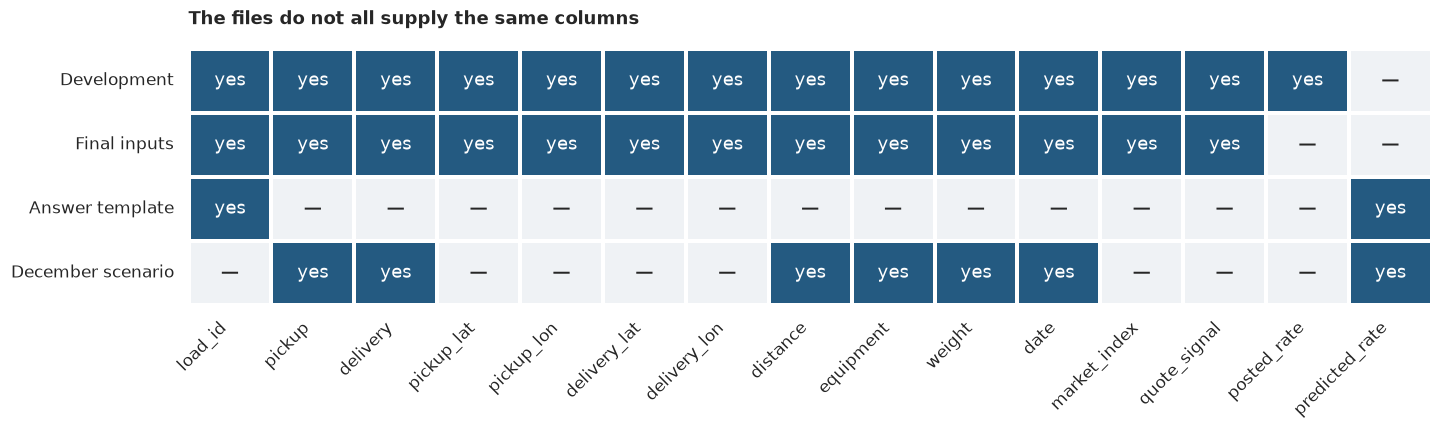

**Potential inputs in development/final data:** 12. **Inputs shared with December:** 6.

Shared: `pickup`, `delivery`, `distance`, `equipment`, `weight`, `date`.

Absent from December: `pickup_lat`, `pickup_lon`, `delivery_lat`, `delivery_lon`, `market_index`, `quote_signal`.

In [3]:
# Presence is different from completeness: a present column may still contain missing values.
column_order = list(train_raw.columns) + ["predicted_rate"]
presence = pd.DataFrame(
    {name: [column in frame.columns for column in column_order] for name, frame in tables.items()},
    index=column_order,
).T
fig, ax = plt.subplots(figsize=(13, 3.8))
sns.heatmap(
    presence.astype(int), annot=presence.replace({True: "yes", False: "—"}),
    fmt="", cmap=sns.color_palette(["#EFF2F5", "#245A81"], as_cmap=True),
    cbar=False, linewidths=1.5, linecolor="white", ax=ax,
)
ax.set_title("The files do not all supply the same columns", pad=16)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.show()

feature_columns = [column for column in train_raw if column not in ["load_id", "posted_rate"]]
common_features = [column for column in feature_columns if column in december_raw]
missing_december = [column for column in feature_columns if column not in december_raw]
display(Markdown(
    f"**Potential inputs in development/final data:** {len(feature_columns)}. "
    f"**Inputs shared with December:** {len(common_features)}.\n\n"
    f"Shared: {', '.join(f'`{column}`' for column in common_features)}.\n\n"
    f"Absent from December: {', '.join(f'`{column}`' for column in missing_december)}."
))

## 2. Audit data quality

This audit uses the original signed values in `train_raw` and `final_inputs_raw`, before the correction below. Count missing values separately from invalid values. A missing weight is not zero, and a negative weight is not a physically valid cargo weight.

Coordinate checks below only test valid latitude/longitude ranges. They do **not** prove that coordinates match the named cities.

The empty `predicted_rate` columns are expected output placeholders, not defects to repair during EDA.

Dataset,Development,Final inputs
Issue,,
Coordinates outside bounds,0,0
Duplicate load ID,0,0
Invalid/missing date,0,0
Missing load ID,0,0
Missing market index,374,249
Missing target,0,<NA>
Missing weight,300,165
Nonpositive distance,0,0
Nonpositive target,0,<NA>


,Development missing,Final inputs missing
date,0,0
delivery,0,0
delivery_lat,0,0
delivery_lon,0,0
distance,0,0
equipment,0,0
load_id,0,0
market_index,374,249
pickup,0,0
pickup_lat,0,0


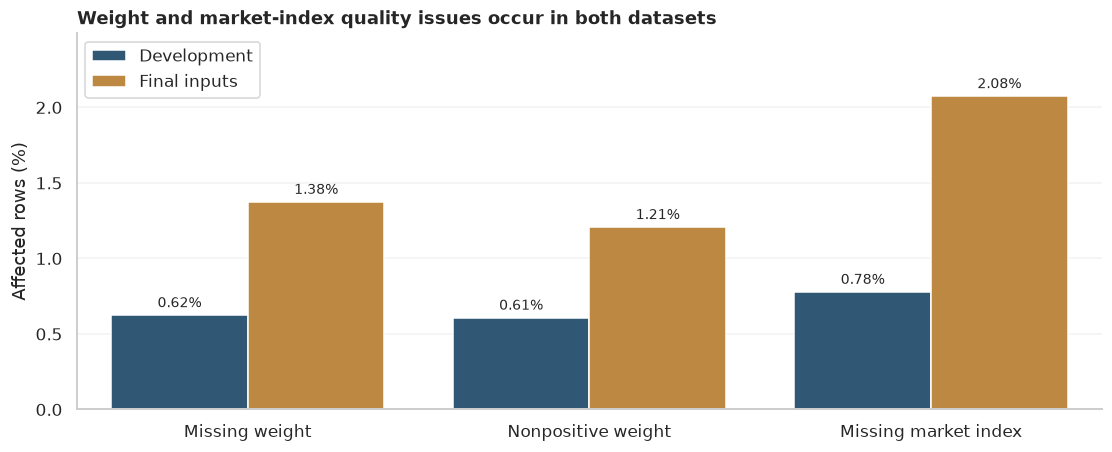

In [4]:
issue_rows = []
for name, frame in {"Development": train_raw, "Final inputs": final_inputs_raw}.items():
    outside_coordinates = (
        (~frame["pickup_lat"].between(-90, 90)) |
        (~frame["delivery_lat"].between(-90, 90)) |
        (~frame["pickup_lon"].between(-180, 180)) |
        (~frame["delivery_lon"].between(-180, 180))
    )
    checks = {
        "Missing weight": frame["weight"].isna(),
        "Nonpositive weight": frame["weight"].le(0),
        "Missing market index": frame["market_index"].isna(),
        "Invalid/missing date": frame["date"].isna(),
        "Missing load ID": frame["load_id"].isna(),
        "Duplicate load ID": frame["load_id"].duplicated(),
        "Nonpositive distance": frame["distance"].le(0),
        "Coordinates outside bounds": outside_coordinates,
        "Repeated rows excluding ID": frame.drop(columns="load_id").duplicated(),
    }
    if "posted_rate" in frame:
        checks["Missing target"] = frame["posted_rate"].isna()
        checks["Nonpositive target"] = frame["posted_rate"].le(0)
    for issue, mask in checks.items():
        issue_rows.append({
            "Dataset": name, "Issue": issue,
            "Count": int(mask.sum()), "Percent": 100 * mask.mean(),
        })

quality = pd.DataFrame(issue_rows)
display(quality.pivot(index="Issue", columns="Dataset", values="Count").astype("Int64"))
display(pd.DataFrame({
    "Development missing": train_raw.isna().sum(),
    "Final inputs missing": final_inputs_raw.isna().sum(),
}).astype("Int64"))

visible_issues = ["Missing weight", "Nonpositive weight", "Missing market index"]
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=quality[quality["Issue"].isin(visible_issues)],
    x="Issue", y="Percent", hue="Dataset", palette=COLORS, ax=ax,
)
ax.set_title("Weight and market-index quality issues occur in both datasets")
ax.set_xlabel("")
ax.set_ylabel("Affected rows (%)")
ax.legend(title="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)
ax.margins(y=0.2)
plt.show()

### Adopted preprocessing: make negative weights positive in memory

**Decision:** convert `weight` to its absolute value in the working pandas DataFrames. This is the selected preprocessing assumption following the analysis in sections 5b-5c; it does not establish the cause of the source error.

- `train`, `final_inputs`, and `december` receive the corrected `weight` column. `dev` and `future` inherit it in the next cell.
- Missing weights remain missing; positive weights and zeros are unchanged.
- `weight_was_negative` records whether the value originally had a negative sign. Reapplying the function preserves this flag.
- `raw_files`, `train_raw`, `final_inputs_raw`, and `december_raw` preserve the original values for audits. The original-sign comparisons in sections 5b-5c use those raw copies.
- This cell does not write a CSV. The correction is repeated in memory whenever the notebook runs.

In [5]:
def clean_weight_sign(frame):
    """Return a corrected copy, preserving missing values and original-sign information."""
    result = frame.copy()
    was_negative = result["weight"].lt(0).fillna(False)
    if "weight_was_negative" in result.columns:
        was_negative = result["weight_was_negative"].fillna(False).astype(bool) | was_negative
    result["weight_was_negative"] = was_negative.astype(bool)
    result["weight"] = result["weight"].abs()
    return result

train = clean_weight_sign(train_raw)
final_inputs = clean_weight_sign(final_inputs_raw)
december = clean_weight_sign(december_raw)

weight_correction_rows = []
for name, source, corrected in [
    ("Development", train_raw, train),
    ("Final inputs", final_inputs_raw, final_inputs),
    ("December scenario", december_raw, december),
]:
    weight_correction_rows.append({
        "Dataset": name,
        "Negative weights before": int(source["weight"].lt(0).sum()),
        "Negative weights after": int(corrected["weight"].lt(0).sum()),
        "Originally-negative flags": int(corrected["weight_was_negative"].sum()),
        "Missing before": int(source["weight"].isna().sum()),
        "Missing after": int(corrected["weight"].isna().sum()),
    })
display(pd.DataFrame(weight_correction_rows).set_index("Dataset"))

,Negative weights before,Negative weights after,Originally-negative flags,Missing before,Missing after
Dataset,,,,,
Development,292,0,292,300,300
Final inputs,145,0,145,165,165
December scenario,0,0,0,0,0


### Prepare analysis-only columns

The working `weight` columns already contain the adopted absolute-value correction. `weight_valid` is a plotting helper that retains corrected positive weights and leaves missing or zero weights unavailable. No missing values are filled and no rows are removed from the datasets.

`weight_was_negative` preserves the original sign as a derived indicator. The original signed weights remain in the raw copies used for auditing.

`rate_per_mile = posted_rate / distance` helps compare trips of different lengths. It is derived from the target, so it is an **EDA outcome**, never an input feature for predicting an unknown price.

Charts that zoom into a central range state how many points are outside the displayed range.

In [6]:
def exploration_view(frame):
    result = frame.copy()
    result["weight_valid"] = result["weight"].where(result["weight"].gt(0))
    result["month"] = result["date"].dt.to_period("M").astype(str)
    result["weekday"] = result["date"].dt.day_name()
    if "posted_rate" in result:
        result["rate_per_mile"] = result["posted_rate"] / result["distance"].where(result["distance"].gt(0))
    return result

dev = exploration_view(train)
future = exploration_view(final_inputs)
equipment_order = ["Dry Van", "Reefer", "Flatbed"]
display(dev[["distance", "weight", "weight_valid", "market_index", "quote_signal",
             "posted_rate", "rate_per_mile"]].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
distance,"48,000.000","1,135.857",728.564,70.000,121.899,550.400,953.300,"1,645.525","2,562.300","3,029.304","3,439.800"
weight,"47,700.000","31,417.249","7,996.515","5,000.000","12,477.980","25,922.000","31,496.000","37,063.250","44,965.200","47,500.000","47,500.000"
weight_valid,"47,700.000","31,417.249","7,996.515","5,000.000","12,477.980","25,922.000","31,496.000","37,063.250","44,965.200","47,500.000","47,500.000"
market_index,"47,626.000",1.083,0.168,0.676,0.783,0.950,1.056,1.220,1.366,1.407,1.468
quote_signal,"48,000.000",2.062,0.291,0.692,1.305,1.891,2.056,2.222,2.551,2.884,3.610
posted_rate,"48,000.000","2,373.981","1,486.493",57.220,327.169,"1,251.555","2,030.760","3,330.750","4,953.766","5,972.834","25,533.000"
rate_per_mile,"48,000.000",2.215,0.584,0.334,1.674,1.987,2.145,2.343,2.736,3.177,14.125


## 3. Understand the target price

The full distribution preserves unusually expensive loads. The second panel zooms into the lower 99% to make the common range readable. The zoom is a display choice, not a decision to delete outliers.

High prices can reflect legitimate loads, corrupted values, or a combination. This notebook flags examples for review without assigning a cause.

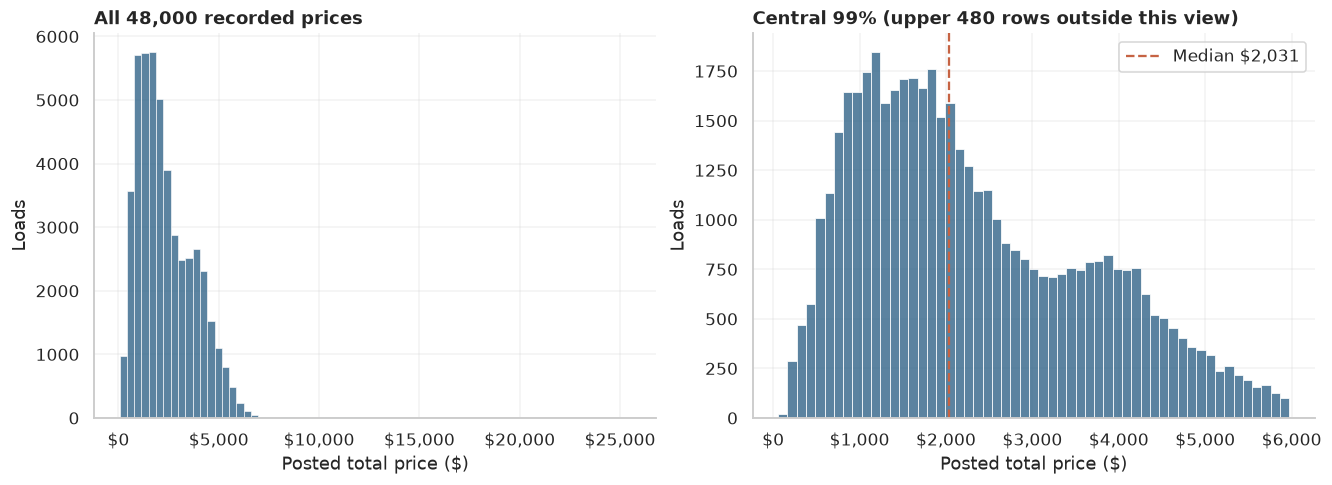

,load_id,pickup,delivery,distance,equipment,weight,date,posted_rate,rate_per_mile
12184,TR-012185,Bakersfield,Hartford,"2,829.800",Dry Van,"33,153.000",2025-03-19,"25,533.000",9.023
37764,TR-037765,Phoenix,Syracuse,"2,810.900",Dry Van,"33,674.000",2025-08-27,"24,294.980",8.643
1466,TR-001467,Los Angeles,Syracuse,"2,786.000",Reefer,"30,322.000",2025-01-10,"24,140.210",8.665
17371,TR-017372,Reno,Philadelphia,"2,777.600",Reefer,"33,158.000",2025-04-20,"23,662.710",8.519
26235,TR-026236,Charleston,Phoenix,"2,552.500",Dry Van,"25,665.000",2025-06-15,"23,580.420",9.238
28219,TR-028220,Tucson,Raleigh,"2,423.300",Dry Van,"30,972.000",2025-06-27,"22,755.660",9.390
3353,TR-003354,Phoenix,Charleston,"2,527.900",Reefer,"36,840.000",2025-01-22,"22,534.650",8.914
40171,TR-040172,Montgomery,Fresno,"2,283.400",Dry Van,"32,447.000",2025-09-11,"20,361.890",8.917


The median recorded price is **$2,030.76**. The 99th percentile is **$5,972.83**, and the maximum is **$25,533.00**. These are descriptions, not cleaning thresholds.

In [7]:
rate_p99 = dev["posted_rate"].quantile(0.99)
central_prices = dev.loc[dev["posted_rate"].le(rate_p99), "posted_rate"]
tail_count = int(dev["posted_rate"].gt(rate_p99).sum())
median_price = dev["posted_rate"].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
sns.histplot(data=dev, x="posted_rate", bins=70, color=COLORS["Development"], ax=axes[0])
axes[0].set_title(f"All {len(dev):,} recorded prices")
sns.histplot(central_prices, bins=55, color=COLORS["Development"], ax=axes[1])
axes[1].axvline(median_price, color="#C66343", linestyle="--", label=f"Median ${median_price:,.0f}")
axes[1].set_title(f"Central 99% (upper {tail_count:,} rows outside this view)")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("Posted total price ($)")
    ax.set_ylabel("Loads")
    ax.xaxis.set_major_formatter(dollars)
plt.show()

display(dev.nlargest(8, "posted_rate")[
    ["load_id", "pickup", "delivery", "distance", "equipment", "weight", "date",
     "posted_rate", "rate_per_mile"]
])
display(Markdown(
    f"The median recorded price is **${median_price:,.2f}**. "
    f"The 99th percentile is **${rate_p99:,.2f}**, and the maximum is "
    f"**${dev['posted_rate'].max():,.2f}**. These are descriptions, not cleaning thresholds."
))

## 4. Distance and equipment

Distance helps describe the scale of the job. In the left panel, hexagons group nearby observations; darker colors indicate more loads. All rows are retained.

The right panel compares total prices across distance bands and equipment types. Each point is a group median, not a fitted model. Equipment comparisons can still reflect different routes and shipment mixes.

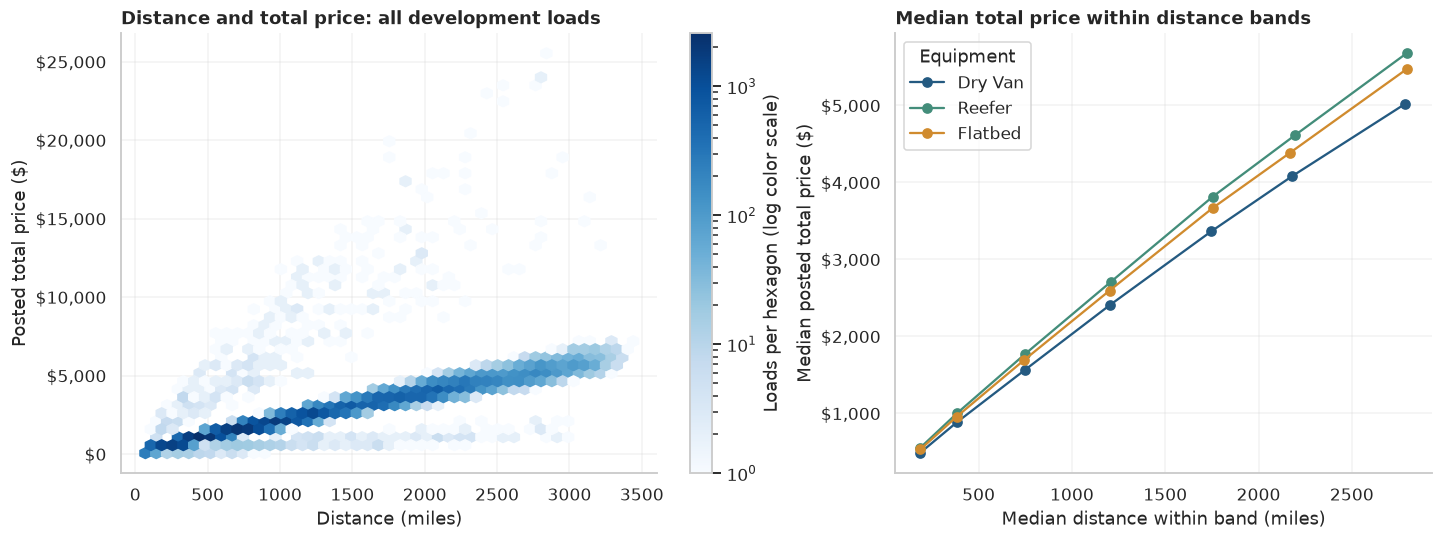

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
density = axes[0].hexbin(
    dev["distance"], dev["posted_rate"], gridsize=45, bins="log",
    mincnt=1, cmap="Blues",
)
fig.colorbar(density, ax=axes[0], label="Loads per hexagon (log color scale)")
axes[0].set_title("Distance and total price: all development loads")
axes[0].set_xlabel("Distance (miles)")
axes[0].set_ylabel("Posted total price ($)")
axes[0].yaxis.set_major_formatter(dollars)

distance_bands = pd.cut(dev["distance"], bins=[0, 250, 500, 1000, 1500, 2000, 2500, 4000])
distance_summary = dev.assign(distance_band=distance_bands).groupby(
    ["distance_band", "equipment"], observed=True
).agg(
    median_distance=("distance", "median"), median_price=("posted_rate", "median"),
    loads=("load_id", "size"),
).reset_index()
for equipment in equipment_order:
    subset = distance_summary[distance_summary["equipment"].eq(equipment)]
    axes[1].plot(subset["median_distance"], subset["median_price"],
                 marker="o", color=EQUIPMENT_COLORS[equipment], label=equipment)
axes[1].set_title("Median total price within distance bands")
axes[1].set_xlabel("Median distance within band (miles)")
axes[1].set_ylabel("Median posted total price ($)")
axes[1].yaxis.set_major_formatter(dollars)
axes[1].legend(title="Equipment")
plt.show()

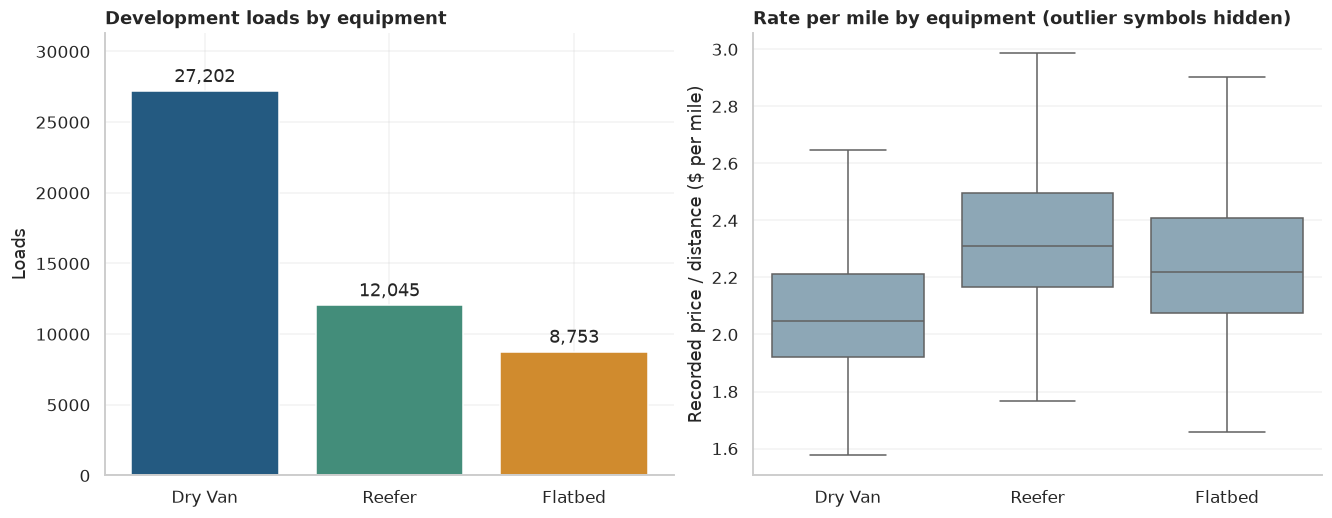

,loads,median_distance_miles,median_valid_weight_lb,median_total_price,median_price_per_mile
equipment,,,,,
Dry Van,27202,957.550,"31,444.000","1,953.035",2.046
Reefer,12045,950.200,"31,577.000","2,196.670",2.312
Flatbed,8753,940.000,"31,532.500","2,076.810",2.220


A box shows the middle 50% of values and its line marks the median. Whiskers extend to observations within 1.5 times the interquartile range. Comparing price per mile reduces the scale effect of distance, but does not control for all other factors.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
equipment_counts = dev["equipment"].value_counts().reindex(equipment_order)
axes[0].bar(equipment_counts.index, equipment_counts.values,
            color=[EQUIPMENT_COLORS[item] for item in equipment_counts.index])
axes[0].set_title("Development loads by equipment")
axes[0].set_ylabel("Loads")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="{:,.0f}", padding=3)
axes[0].margins(y=0.15)

# Outlier symbols are hidden only in this boxplot; all rows still define the quartiles.
sns.boxplot(data=dev, x="equipment", y="rate_per_mile", order=equipment_order,
            color="#86A9BD", showfliers=False, ax=axes[1])
axes[1].set_title("Rate per mile by equipment (outlier symbols hidden)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Recorded price / distance ($ per mile)")
plt.show()

display(dev.groupby("equipment", observed=True).agg(
    loads=("load_id", "size"),
    median_distance_miles=("distance", "median"),
    median_valid_weight_lb=("weight_valid", "median"),
    median_total_price=("posted_rate", "median"),
    median_price_per_mile=("rate_per_mile", "median"),
).reindex(equipment_order))
display(Markdown(
    "A box shows the middle 50% of values and its line marks the median. "
    "Whiskers extend to observations within 1.5 times the interquartile range. "
    "Comparing price per mile reduces the scale effect of distance, but does not control for all other factors."
))

## 5. Weight and the price relationship

The weight histogram uses corrected positive weights, including originally negative records after applying `abs()`. Missing weights remain excluded from weight-specific views; no missing values are imputed.

The right panel summarizes median price per mile within weight bands. It is a descriptive association that can also reflect route, equipment, and date differences.

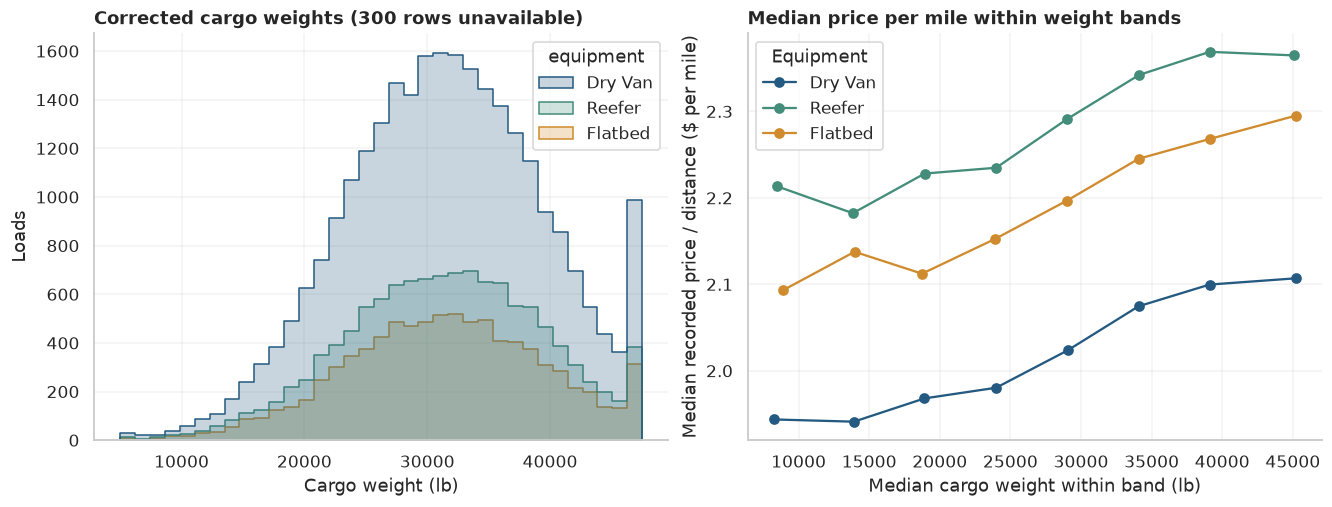

In [10]:
valid_weight_rows = dev[dev["weight_valid"].notna()].copy()
excluded_weight_rows = len(dev) - len(valid_weight_rows)
valid_weight_rows["weight_band"] = pd.cut(valid_weight_rows["weight_valid"], bins=8)
weight_summary = valid_weight_rows.groupby(
    ["weight_band", "equipment"], observed=True
).agg(
    median_weight=("weight_valid", "median"),
    median_rpm=("rate_per_mile", "median"),
    loads=("load_id", "size"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=valid_weight_rows, x="weight_valid", hue="equipment",
             hue_order=equipment_order, palette=EQUIPMENT_COLORS,
             bins=35, element="step", ax=axes[0])
axes[0].set_title(f"Corrected cargo weights ({excluded_weight_rows:,} rows unavailable)")
axes[0].set_xlabel("Cargo weight (lb)")
axes[0].set_ylabel("Loads")
for equipment in equipment_order:
    subset = weight_summary[weight_summary["equipment"].eq(equipment)]
    axes[1].plot(subset["median_weight"], subset["median_rpm"],
                 marker="o", color=EQUIPMENT_COLORS[equipment], label=equipment)
axes[1].set_title("Median price per mile within weight bands")
axes[1].set_xlabel("Median cargo weight within band (lb)")
axes[1].set_ylabel("Median recorded price / distance ($ per mile)")
axes[1].legend(title="Equipment")
plt.show()

### 5b. Could negative weights be sign-entry errors?

**Preliminary marginal check:** the distributions below cannot establish whether the magnitudes are correct. Section 5c evaluates relationships with other load attributes.

**Hypothesis:** some weights may have the correct magnitude but an incorrect minus sign. For this diagnostic only, compare positive weights with **the absolute values of negative weights**, separately in development and final-input data.

These groups contain different shipments, so there is no valid row-by-row Pearson correlation between them. Correlating `weight` with its own absolute value inside the negative group would always give -1 and would not test this hypothesis. Instead, examine:
- **Distributions:** do the magnitudes occupy similar ranges with similar shapes?
- **Quantiles:** do their 5th, 10th, ..., 95th percentiles align?
- **Equipment groups:** does the resemblance remain when comparing the same trailer type?

The negative group is much smaller, so raw histogram counts would be misleading. Each histogram below shows the percentage of its own group in shared 2,500-lb bins.

For each quantile plot, the shaded band comes from **1,000 repeated samples from the positive weights**, with each sample the same size as the negative group. The band shows the 2.5th-97.5th percentile at each quantile: the sampling variation expected if the negative magnitudes followed the positive-weight distribution. It is a **pointwise reference band**, not a simultaneous confidence statement or proof of identical distributions.

These diagnostic plots use preserved original signed weights. The working DataFrames use the adopted absolute-value correction from section 2; source CSVs remain unchanged.

In [11]:
# Use preserved signed originals so this diagnostic remains valid after working weights are corrected.
weight_sign_frames = {"Development": train_raw, "Final inputs": final_inputs_raw}
weight_sign_colors = {"Positive weights": "#245A81", "Magnitude of negative weights": "#C66343"}
weight_sign_samples = {}
weight_sign_rows = []
weight_sign_overview = []

for dataset_name, frame in weight_sign_frames.items():
    positive = frame.loc[frame["weight"].gt(0), "weight"].dropna().to_numpy(dtype=float)
    negative_magnitude = frame.loc[frame["weight"].lt(0), "weight"].abs().dropna().to_numpy(dtype=float)
    if not len(positive) or not len(negative_magnitude):
        raise ValueError(f"{dataset_name}: both positive and negative weights are needed.")
    weight_sign_samples[dataset_name] = (positive, negative_magnitude)
    for group_name, values in [
        ("Positive weights", positive),
        ("Magnitude of negative weights", negative_magnitude),
    ]:
        weight_sign_rows.append({
            "Dataset": dataset_name, "Group": group_name, "Loads": len(values),
            "Mean (lb)": values.mean(), "Std. deviation (lb)": values.std(ddof=1),
            "Minimum (lb)": values.min(), "5th percentile (lb)": np.quantile(values, 0.05),
            "25th percentile (lb)": np.quantile(values, 0.25),
            "Median (lb)": np.median(values),
            "75th percentile (lb)": np.quantile(values, 0.75),
            "95th percentile (lb)": np.quantile(values, 0.95),
            "Maximum (lb)": values.max(),
        })
    weight_sign_overview.append({
        "Dataset": dataset_name,
        "Positive loads": len(positive),
        "Negative loads": len(negative_magnitude),
        "Missing weights": int(frame["weight"].isna().sum()),
        "Negative median minus positive median (lb)": np.median(negative_magnitude) - np.median(positive),
        "Negative magnitudes inside positive observed range (%)":
            100 * np.mean((negative_magnitude >= positive.min()) & (negative_magnitude <= positive.max())),
    })

weight_sign_summary = pd.DataFrame(weight_sign_rows)
display(weight_sign_summary.set_index(["Dataset", "Group"]).round(1))
display(pd.DataFrame(weight_sign_overview).set_index("Dataset").round(1))

Loads  Mean (lb)  Std. deviation (lb)  Minimum (lb)  5th percentile (lb)  25th percentile (lb)  \
Dataset      Group                                                                                                                           
Development  Positive weights               47408 31,415.400            7,994.900     5,000.000           18,004.400            25,922.000   
             Magnitude of negative weights    292 31,724.200            8,262.500     5,000.000           18,965.500            25,928.500   
Final inputs Positive weights               11690 31,278.000            7,986.800     5,000.000           18,008.400            25,746.500   
             Magnitude of negative weights    145 31,681.800            8,094.200     8,229.000           17,436.400            26,289.000   

                                            Median (lb)  75th percentile (lb)  95th percentile (lb)  Maximum (lb)  
Dataset      Group                                                                                                 
Development  Positive weights                31,493.500            37,063.000            44,961.600    47,500.000  
             Magnitude of negative weights   31,821.500            37,284.200            46,070.400    47,500.000  
Final inputs Positive weights                31,323.500            36,922.000            44,690.100    47,500.000  
             Magnitude of negative weights   32,517.000            37,679.000            44,557.600    47,500.000

,Positive loads,Negative loads,Missing weights,Negative median minus positive median (lb),Negative magnitudes inside positive observed range (%)
Dataset,,,,,
Development,47408,292,300,328.000,100.000
Final inputs,11690,145,165,"1,193.500",100.000


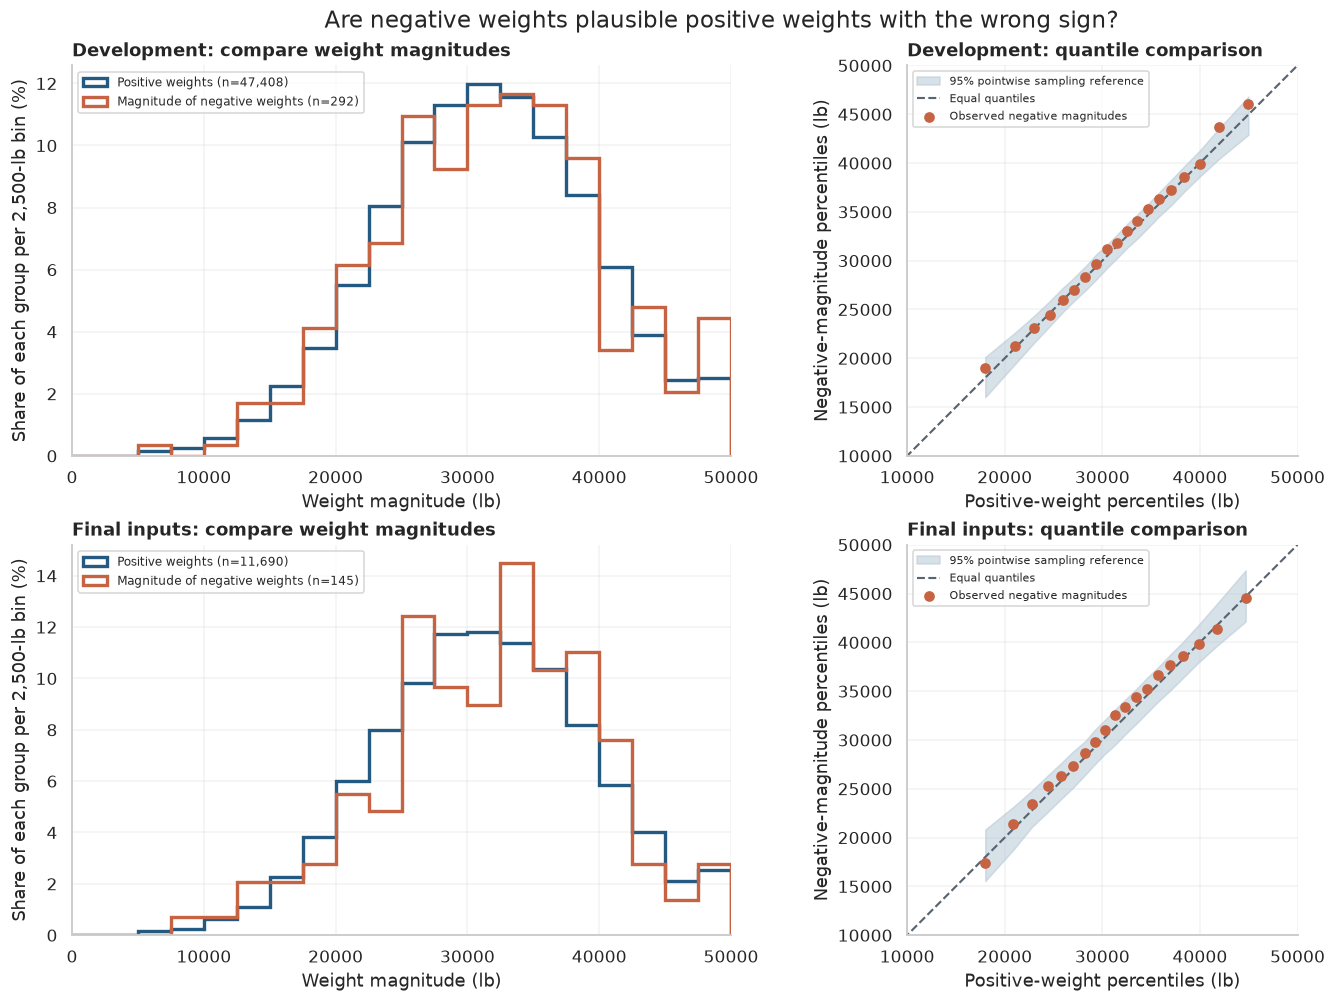

,Plotted quantiles,Quantiles inside pointwise reference
Dataset,,
Development,19,18
Final inputs,19,19


**Reading the right-hand plots:** points near the dashed diagonal mean the two groups have similar percentiles. The shaded area accounts for the smaller negative sample. The percentile checks are related to one another, so their count is descriptive, not a hypothesis-test p-value.

In [12]:
weight_sign_rng = np.random.default_rng(SEED)
weight_sign_quantiles = np.arange(0.05, 0.96, 0.05)
weight_sign_bootstrap_count = 1000
weight_sign_bins = np.arange(0, 50000 + 2500, 2500)
weight_sign_checks = []
weight_sign_fig, weight_sign_axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (dataset_name, (positive, negative_magnitude)) in enumerate(weight_sign_samples.items()):
    ax_hist, ax_qq = weight_sign_axes[row]
    for group_name, values in [
        ("Positive weights", positive),
        ("Magnitude of negative weights", negative_magnitude),
    ]:
        ax_hist.hist(
            values, bins=weight_sign_bins, weights=np.full(len(values), 100 / len(values)),
            histtype="step", linewidth=2.2, color=weight_sign_colors[group_name],
            label=f"{group_name} (n={len(values):,})",
        )
    ax_hist.set_title(f"{dataset_name}: compare weight magnitudes")
    ax_hist.set_xlabel("Weight magnitude (lb)")
    ax_hist.set_ylabel("Share of each group per 2,500-lb bin (%)")
    ax_hist.set_xlim(0, 50000)
    ax_hist.legend(fontsize=8, loc="upper left")

    positive_quantiles = np.quantile(positive, weight_sign_quantiles)
    negative_quantiles = np.quantile(negative_magnitude, weight_sign_quantiles)
    reference_samples = weight_sign_rng.choice(
        positive, size=(weight_sign_bootstrap_count, len(negative_magnitude)), replace=True
    )
    reference_quantiles = np.quantile(reference_samples, weight_sign_quantiles, axis=1)
    reference_low, reference_high = np.quantile(reference_quantiles, [0.025, 0.975], axis=1)

    ax_qq.fill_between(positive_quantiles, reference_low, reference_high,
                       color="#B7C9D6", alpha=0.55, label="95% pointwise sampling reference")
    ax_qq.plot([0, 50000], [0, 50000], linestyle="--", color="#586571",
               linewidth=1.4, label="Equal quantiles")
    ax_qq.scatter(positive_quantiles, negative_quantiles, s=36,
                  color=weight_sign_colors["Magnitude of negative weights"], zorder=3,
                  label="Observed negative magnitudes")
    ax_qq.set_title(f"{dataset_name}: quantile comparison")
    ax_qq.set_xlabel("Positive-weight percentiles (lb)")
    ax_qq.set_ylabel("Negative-magnitude percentiles (lb)")
    ax_qq.set_xlim(10000, 50000)
    ax_qq.set_ylim(10000, 50000)
    ax_qq.set_aspect("equal", adjustable="box")
    ax_qq.legend(fontsize=7.5, loc="upper left")
    weight_sign_checks.append({
        "Dataset": dataset_name,
        "Plotted quantiles": len(weight_sign_quantiles),
        "Quantiles inside pointwise reference":
            int(((negative_quantiles >= reference_low) & (negative_quantiles <= reference_high)).sum()),
    })

weight_sign_fig.suptitle("Are negative weights plausible positive weights with the wrong sign?", fontsize=15)
weight_sign_output_dir = PROJECT_ROOT / "outputs" / "eda"
weight_sign_output_dir.mkdir(parents=True, exist_ok=True)
weight_sign_plot_path = weight_sign_output_dir / "negative_weight_comparison.png"
weight_sign_fig.savefig(weight_sign_plot_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(weight_sign_fig)
display(pd.DataFrame(weight_sign_checks).set_index("Dataset"))
display(Markdown(
    "**Reading the right-hand plots:** points near the dashed diagonal mean the two groups have "
    "similar percentiles. The shaded area accounts for the smaller negative sample. "
    "The percentile checks are related to one another, so their count is descriptive, not a hypothesis-test p-value."
))

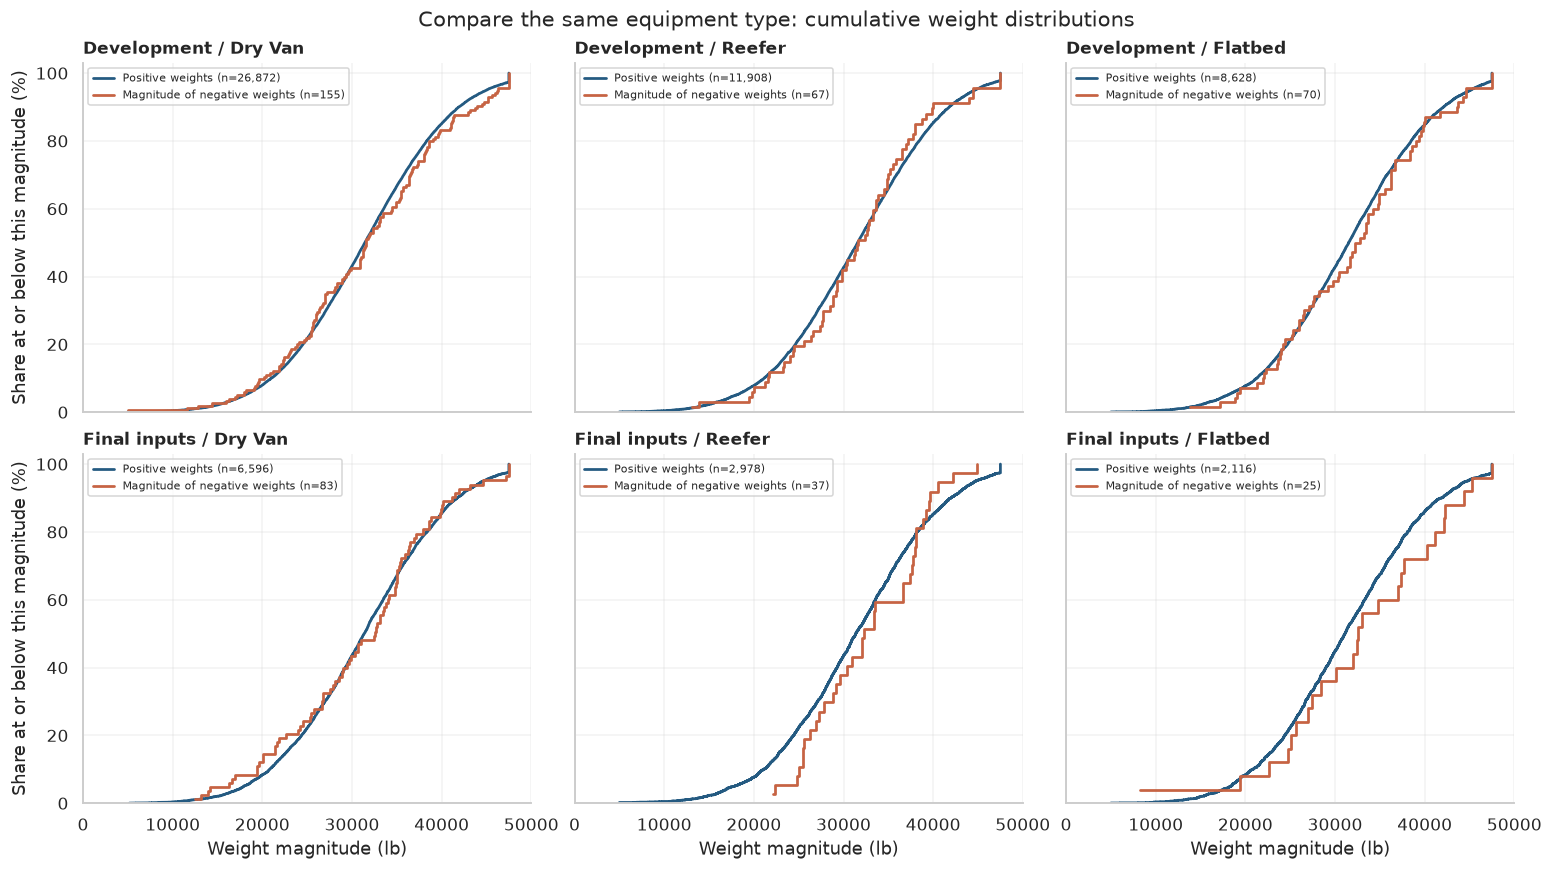

Loads  Median magnitude (lb)
Dataset      Equipment Group                                                      
Development  Dry Van   Positive weights               26872             31,442.500
                       Magnitude of negative weights    155             31,558.000
             Reefer    Positive weights               11908             31,576.500
                       Magnitude of negative weights     67             31,578.000
             Flatbed   Positive weights                8628             31,525.000
                       Magnitude of negative weights     70             32,536.000
Final inputs Dry Van   Positive weights                6596             31,357.000
                       Magnitude of negative weights     83             32,565.000
             Reefer    Positive weights                2978             31,371.000
                       Magnitude of negative weights     37             32,298.000
             Flatbed   Positive weights                2116             31,110.500
                       Magnitude of negative weights     25             32,517.000

A cumulative curve reports the percentage of loads at or below each weight. Overlapping curves indicate similar distributions. Negative groups are small, especially within equipment, so modest gaps are expected and differences should not be dismissed or overinterpreted.

In [13]:
# Compare within equipment to check whether overall similarity hides a different equipment mix.
weight_equipment_fig, weight_equipment_axes = plt.subplots(2, 3, figsize=(14, 7.8), sharex=True, sharey=True)
weight_equipment_rows = []
for row, (dataset_name, frame) in enumerate(weight_sign_frames.items()):
    for col, equipment_name in enumerate(equipment_order):
        ax = weight_equipment_axes[row, col]
        equipment_frame = frame.loc[frame["equipment"].eq(equipment_name)]
        equipment_samples = {
            "Positive weights": equipment_frame.loc[equipment_frame["weight"].gt(0), "weight"].to_numpy(dtype=float),
            "Magnitude of negative weights":
                equipment_frame.loc[equipment_frame["weight"].lt(0), "weight"].abs().to_numpy(dtype=float),
        }
        for group_name, values in equipment_samples.items():
            if not len(values):
                continue
            ordered = np.sort(values)
            cumulative_percent = 100 * np.arange(1, len(values) + 1) / len(values)
            ax.step(ordered, cumulative_percent, where="post", linewidth=1.8,
                    color=weight_sign_colors[group_name],
                    label=f"{group_name} (n={len(values):,})")
            weight_equipment_rows.append({
                "Dataset": dataset_name, "Equipment": equipment_name, "Group": group_name,
                "Loads": len(values), "Median magnitude (lb)": np.median(values),
            })
        ax.set_title(f"{dataset_name} / {equipment_name}", fontsize=11)
        ax.legend(fontsize=7, loc="upper left")
        ax.set_xlim(0, 50000)
        ax.set_ylim(0, 103)
        if row == 1:
            ax.set_xlabel("Weight magnitude (lb)")
        if col == 0:
            ax.set_ylabel("Share at or below this magnitude (%)")

weight_equipment_fig.suptitle("Compare the same equipment type: cumulative weight distributions", fontsize=14)
weight_equipment_fig.savefig(
    weight_sign_output_dir / "negative_weight_by_equipment.png",
    dpi=150, bbox_inches="tight", facecolor="white",
)
plt.show()
plt.close(weight_equipment_fig)
display(pd.DataFrame(weight_equipment_rows).set_index(["Dataset", "Equipment", "Group"]).round(1))
display(Markdown(
    "A cumulative curve reports the percentage of loads at or below each weight. "
    "Overlapping curves indicate similar distributions. Negative groups are small, especially within equipment, "
    "so modest gaps are expected and differences should not be dismissed or overinterpreted."
))

In [14]:
weight_sign_findings = []
for dataset_name, (positive, negative_magnitude) in weight_sign_samples.items():
    median_positive = np.median(positive)
    median_negative = np.median(negative_magnitude)
    weight_sign_findings.append(
        f"- **{dataset_name}:** {len(negative_magnitude):,} negative weights versus {len(positive):,} positive weights. "
        f"Median magnitude is **{median_negative:,.1f} lb** for the negatives and "
        f"**{median_positive:,.1f} lb** for the positives "
        f"(difference **{median_negative - median_positive:+,.1f} lb**, "
        f"or **{100 * (median_negative / median_positive - 1):+.1f}%**)."
    )
display(Markdown("\n".join(weight_sign_findings)))
display(Markdown(
    "**Preliminary observation only:** similar medians and distributions do not establish that the "
    "negative magnitudes are correct. The groups are different shipments, and resemblance in one variable "
    "does not show that its relationships with price, distance, location, or time are preserved. "
    "Use the relationship analysis in section 5c for the substantive assessment. The selected working-DataFrame correction is documented in section 2; this diagnostic reads the preserved raw values."
))

- **Development:** 292 negative weights versus 47,408 positive weights. Median magnitude is **31,821.5 lb** for the negatives and **31,493.5 lb** for the positives (difference **+328.0 lb**, or **+1.0%**).
- **Final inputs:** 145 negative weights versus 11,690 positive weights. Median magnitude is **32,517.0 lb** for the negatives and **31,323.5 lb** for the positives (difference **+1,193.5 lb**, or **+3.8%**).

**Preliminary observation only:** similar medians and distributions do not establish that the negative magnitudes are correct. The groups are different shipments, and resemblance in one variable does not show that its relationships with price, distance, location, or time are preserved. Use the relationship analysis in section 5c for the substantive assessment. The selected working-DataFrame correction is documented in section 2; this diagnostic reads the preserved raw values.

### Limit of the marginal comparison

**Conclusion:** similar medians, ranges, and percentiles are insufficient evidence that a minus sign is the only error. They motivate a hypothesis but cannot establish that the magnitudes belong to these shipments. The substantive assessment is the attribute and comparable-load analysis in section 5c.

The table summarizes the supplied CSVs at the time of this analysis. The preceding code cells calculate the detailed statistics and plots when rerun.

| Dataset | Positive loads | Negative loads | Positive median (lb) | Negative-magnitude median (lb) | Relative median difference |
|---|---:|---:|---:|---:|---:|
| Development | 47,408 | 292 | 31,493.5 | 31,821.5 | +1.0% |
| Final inputs | 11,690 | 145 | 31,323.5 | 32,517.0 | +3.8% |

**How to read the evidence**

- In the distribution plots, blue represents positive weights and orange represents the absolute values of negative weights. Their ranges and overall shapes largely overlap. Percentages are used because the group sizes differ substantially.
- In the quantile plots, points near the diagonal indicate similar percentiles. Most points fall within the pointwise sampling reference band constructed using samples as small as the negative group. This is descriptive evidence, not a probability that the sign-error explanation is correct.
- The equipment-specific plots help check whether the overall similarity is explained only by trailer mix. The curves broadly resemble one another, but differences remain, particularly in small final-input subgroups such as Flatbed, which has only 25 negative observations.
- Every negative-weight magnitude falls within the positive-weight range of its corresponding dataset. Range overlap, percentile similarity, and median similarity remain marginal checks. They cannot establish preservation of relationships with other load attributes.

**Why we did not calculate a direct correlation**

Positive and negative records represent different shipments, without a justified one-to-one pairing. Correlating arbitrarily paired or sorted values would not establish a relationship between shipments. Within the negative group, correlating a weight with its own absolute value produces -1 by construction and says nothing about the cause of the negative sign.

**Selected preprocessing and optional later sensitivity comparison**

The selected treatment is absolute-value correction in the working DataFrames, retaining `weight_was_negative` and leaving missing weights missing. A later sensitivity comparison may examine the following treatments on the same chronological periods:

1. **Missing-value treatment:** replace negative weights with missing values and handle missingness in the training pipeline.
2. **Sign-correction treatment:** replace negative weights with their absolute values, while leaving originally missing values missing.

For both treatments, retain a `weight_was_negative` indicator and use the same model, input features, folds, and evaluation metrics. Fit any learned preprocessing on each training portion only. Compare overall errors and errors specifically for originally negative-weight loads. Use development-data validation to assess the selected treatment and any alternatives; the final-input file has no target labels.

Better held-out performance can support a useful predictive treatment, but cannot prove a data-entry cause. Confirming that cause would require source-system documentation or corrected source records.

**Current status:** absolute-value correction is adopted for the working DataFrames. These plots retain the original signed groups by reading raw copies. Source CSVs remain unchanged, and the data-entry cause remains unconfirmed.


### 5c. Do the negative magnitudes preserve relationships with other attributes?

**This is the substantive test of the sign-error hypothesis.** Section 5b only compared marginal distributions. Similar medians or histograms cannot establish that the magnitudes are correct.

If a minus sign is the main error, removing it should preserve meaningful associations with the load's other attributes, particularly the recorded price after accounting for shipment context.

We examine three levels:
1. **Attribute relationships:** compare rank correlations of weight magnitude with price, distance, market/quote signals, date, and supplied origin/destination coordinates. Price relationships are available only in development data.
2. **Equipment-specific price relationships:** compare the direction and shape of weight versus price per mile within each trailer type.
3. **Comparable-load analysis:** compare each load with positive-weight peers on the same directional route and equipment, close in date, distance, and market index. Then test whether a heavier-than-peer load also has a higher-than-peer price per mile.

The matched analysis is descriptive. It uses peers from the labeled period on either side of a query date, so it is **not chronological model validation** and does not measure future prediction accuracy. No production model is trained. Absolute-value correction is adopted in the working DataFrames; this diagnostic continues to use the original signed records.

In [15]:
# Diagnose original signs using preserved raw copies, independently of corrected working DataFrames.
wr_frames = {}
for wr_dataset, wr_source in {"Development": train_raw, "Final inputs": final_inputs_raw}.items():
    wr_frame = wr_source.loc[wr_source["weight"].notna() & wr_source["weight"].ne(0)].copy()
    wr_frame["weight_magnitude"] = wr_frame["weight"].abs()
    wr_frame["originally_negative"] = wr_frame["weight"].lt(0)
    wr_frame["calendar_month"] = wr_frame["date"].dt.to_period("M").astype(str)
    wr_frame["date_days"] = (wr_frame["date"] - pd.Timestamp("2025-01-01")).dt.days
    if "posted_rate" in wr_frame:
        wr_frame["price_per_mile"] = wr_frame["posted_rate"] / wr_frame["distance"]
    wr_frames[wr_dataset] = wr_frame
wr_colors = {"Positive weights": "#245A81", "Negative magnitudes": "#C66343"}
wr_rng = np.random.default_rng(20261004)
wr_output_dir = PROJECT_ROOT / "outputs" / "eda"
wr_output_dir.mkdir(parents=True, exist_ok=True)

def wr_spearman(x, y):
    pairs = pd.DataFrame({"x": np.asarray(x), "y": np.asarray(y)}).replace(
        [np.inf, -np.inf], np.nan).dropna()
    if len(pairs) < 3 or pairs["x"].nunique() < 2 or pairs["y"].nunique() < 2:
        return np.nan
    return pairs.corr(method="spearman").loc["x", "y"]

def wr_row_spearman(x, y):
    """Rank correlation separately for each row of two finite 2D arrays."""
    x_rank = pd.DataFrame(x).rank(axis=1, method="average").to_numpy(dtype=float)
    y_rank = pd.DataFrame(y).rank(axis=1, method="average").to_numpy(dtype=float)
    x_centered = x_rank - x_rank.mean(axis=1, keepdims=True)
    y_centered = y_rank - y_rank.mean(axis=1, keepdims=True)
    denominator = np.sqrt(np.sum(x_centered ** 2, axis=1) * np.sum(y_centered ** 2, axis=1))
    return np.divide(np.sum(x_centered * y_centered, axis=1), denominator,
                     out=np.full(len(x_rank), np.nan), where=denominator > 0)

def wr_bootstrap_correlation(x, y, repetitions=1000):
    pairs = pd.DataFrame({"x": np.asarray(x), "y": np.asarray(y)}).replace(
        [np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    if len(pairs) < 5:
        return (np.nan, np.nan)
    indices = wr_rng.integers(0, len(pairs), size=(repetitions, len(pairs)))
    correlations = wr_row_spearman(pairs[indices, 0], pairs[indices, 1])
    return tuple(np.nanquantile(correlations, [0.025, 0.975]))

wr_attribute_labels = {
    "posted_rate": "Total posted price",
    "price_per_mile": "Posted price per mile",
    "distance": "Distance",
    "market_index": "Market index",
    "quote_signal": "Quote signal",
    "date_days": "Date",
    "pickup_lat": "Pickup latitude",
    "pickup_lon": "Pickup longitude",
    "delivery_lat": "Delivery latitude",
    "delivery_lon": "Delivery longitude",
}
wr_correlations = []
for dataset, frame in wr_frames.items():
    for attribute, label in wr_attribute_labels.items():
        if attribute not in frame:
            continue
        positive = frame.loc[~frame["originally_negative"], ["weight_magnitude", attribute]].dropna()
        negative = frame.loc[frame["originally_negative"], ["weight_magnitude", attribute]].dropna()
        lower, upper = wr_bootstrap_correlation(negative["weight_magnitude"], negative[attribute])
        wr_correlations.append({
            "Dataset": dataset, "Attribute": label,
            "Positive n": len(positive), "Negative n": len(negative),
            "Positive correlation": wr_spearman(positive["weight_magnitude"], positive[attribute]),
            "Negative-magnitude correlation": wr_spearman(negative["weight_magnitude"], negative[attribute]),
            "Negative bootstrap lower": lower, "Negative bootstrap upper": upper,
        })
wr_correlation_table = pd.DataFrame(wr_correlations)
display(wr_correlation_table.round(3))

,Dataset,Attribute,Positive n,Negative n,Positive correlation,Negative-magnitude correlation,Negative bootstrap lower,Negative bootstrap upper
0,Development,Total posted price,47408,292,0.042,0.053,-0.076,0.170
1,Development,Posted price per mile,47408,292,0.199,0.152,0.041,0.271
2,Development,Distance,47408,292,0.003,0.015,-0.100,0.131
3,Development,Market index,47038,289,0.002,0.052,-0.065,0.162
4,Development,Quote signal,47408,292,0.005,-0.025,-0.143,0.097
5,Development,Date,47408,292,0.007,-0.097,-0.211,0.028
6,Development,Pickup latitude,47408,292,-0.000,-0.060,-0.178,0.050
7,Development,Pickup longitude,47408,292,0.003,-0.083,-0.202,0.046
8,Development,Delivery latitude,47408,292,-0.005,0.041,-0.071,0.157
9,Development,Delivery longitude,47408,292,-0.001,0.032,-0.089,0.151


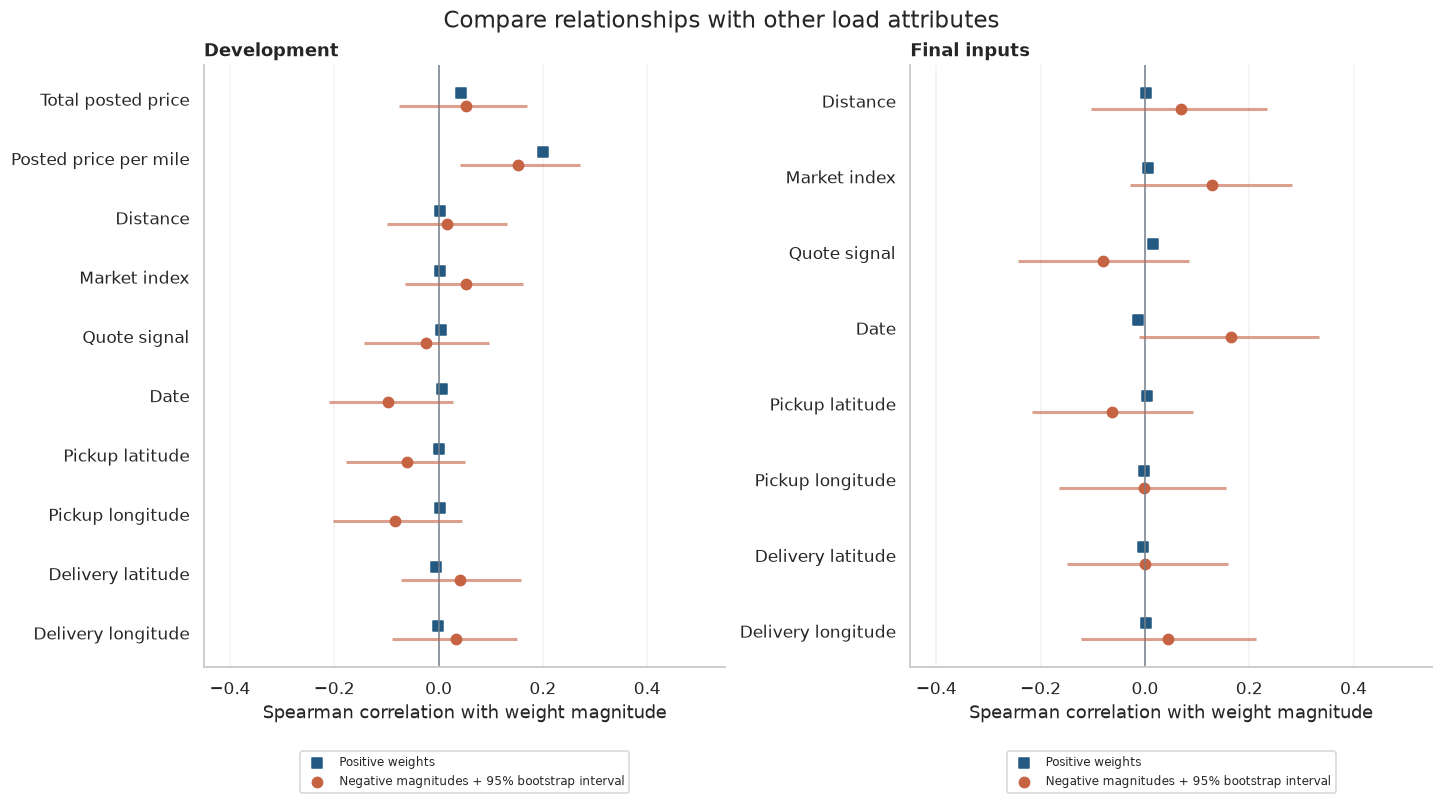

**Interpretation:** a near-zero correlation in both groups gives little evidence about whether the magnitudes are right. Price per mile is more informative here than total price because distance dominates total price. The intervals describe sampling uncertainty in the smaller negative groups under an independent-row bootstrap assumption; overlapping intervals do not establish equivalence. These are pooled associations, so route, time, and equipment composition may still affect them.

In [16]:
wr_fig, wr_axes = plt.subplots(1, 2, figsize=(13, 7.2))
for ax, dataset in zip(wr_axes, wr_frames):
    table = wr_correlation_table.loc[wr_correlation_table["Dataset"].eq(dataset)].reset_index(drop=True)
    positions = np.arange(len(table))
    ax.axvline(0, color="#75808A", linewidth=1)
    # Draw bootstrap intervals separately; percentile intervals need not contain a point estimate.
    ax.hlines(positions + 0.11, table["Negative bootstrap lower"], table["Negative bootstrap upper"],
              color=wr_colors["Negative magnitudes"], alpha=0.6, linewidth=2)
    ax.scatter(table["Positive correlation"], positions - 0.11, color=wr_colors["Positive weights"],
                s=40, marker="s", label="Positive weights")
    ax.scatter(table["Negative-magnitude correlation"], positions + 0.11,
                color=wr_colors["Negative magnitudes"], s=45,
                label="Negative magnitudes + 95% bootstrap interval")
    ax.set_yticks(positions, table["Attribute"])
    ax.invert_yaxis()
    ax.set_xlim(-0.45, 0.55)
    ax.set_title(dataset)
    ax.set_xlabel("Spearman correlation with weight magnitude")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=8)
    ax.grid(axis="y", visible=False)
wr_fig.suptitle("Compare relationships with other load attributes", fontsize=15)
wr_fig.savefig(wr_output_dir / "negative_weight_attribute_relationships.png", dpi=150,
               bbox_inches="tight", facecolor="white")
plt.show()
plt.close(wr_fig)
display(Markdown(
    "**Interpretation:** a near-zero correlation in both groups gives little evidence about whether "
    "the magnitudes are right. Price per mile is more informative here than total price because "
    "distance dominates total price. The intervals describe sampling uncertainty in the smaller negative groups "
    "under an independent-row bootstrap assumption; overlapping intervals do not establish equivalence. "
    "These are pooled associations, so route, time, and equipment composition may still affect them."
))

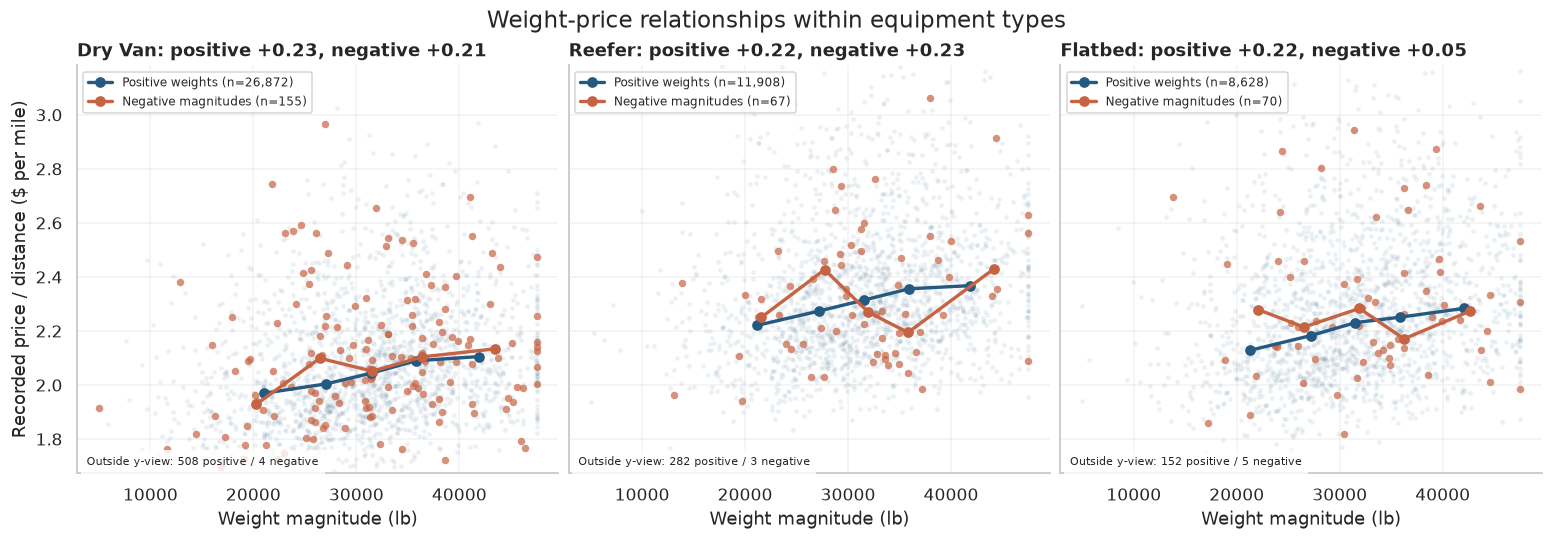

,Positive n,Negative n,Positive correlation,Negative-magnitude correlation,Negative bootstrap lower,Negative bootstrap upper
Equipment,,,,,,
Dry Van,26872,155,0.232,0.208,0.051,0.367
Reefer,11908,67,0.222,0.231,-0.029,0.446
Flatbed,8628,70,0.224,0.054,-0.195,0.294


Lines show median price per mile within five common weight bands, using all observations. Scatter points are a display sample and the y-axis shows the pooled 1st-99th percentile range. All valid observations are used for correlations and uncertainty estimates. The Dry Van and Reefer associations are similar across signs; the negative Flatbed group has a weaker pooled association. This is mixed evidence, not uniform agreement.

In [17]:
wr_dev = wr_frames["Development"]
wr_equipment_rows = []
wr_fig, wr_axes = plt.subplots(1, 3, figsize=(14, 4.8), sharex=True, sharey=True)
wr_y_low, wr_y_high = wr_dev["price_per_mile"].quantile([0.01, 0.99])

for ax, equipment in zip(wr_axes, equipment_order):
    frame = wr_dev.loc[wr_dev["equipment"].eq(equipment)]
    positive = frame.loc[~frame["originally_negative"]]
    negative = frame.loc[frame["originally_negative"]]
    # Common quintile boundaries defined from positive weights in this equipment group.
    edges = np.unique(np.quantile(positive["weight_magnitude"], np.linspace(0, 1, 6)))
    edges[0], edges[-1] = -np.inf, np.inf
    for name, group in [("Positive weights", positive), ("Negative magnitudes", negative)]:
        visible = group.loc[group["price_per_mile"].between(wr_y_low, wr_y_high)]
        sampled = visible.sample(n=min(len(visible), 1800), random_state=SEED)
        ax.scatter(sampled["weight_magnitude"], sampled["price_per_mile"],
                    s=9 if name == "Positive weights" else 24,
                    alpha=0.09 if name == "Positive weights" else 0.7,
                    color=wr_colors[name], linewidths=0)
        banded = group.assign(weight_band=pd.cut(group["weight_magnitude"], bins=edges))
        trend = banded.groupby("weight_band", observed=True).agg(
            weight=("weight_magnitude", "median"), price=("price_per_mile", "median"),
            loads=("load_id", "size"),
        )
        ax.plot(trend["weight"], trend["price"], color=wr_colors[name], marker="o",
                 linewidth=2.2, label=f"{name} (n={len(group):,})")
    positive_r = wr_spearman(positive["weight_magnitude"], positive["price_per_mile"])
    negative_r = wr_spearman(negative["weight_magnitude"], negative["price_per_mile"])
    lower, upper = wr_bootstrap_correlation(negative["weight_magnitude"], negative["price_per_mile"])
    wr_equipment_rows.append({
        "Equipment": equipment, "Positive n": len(positive), "Negative n": len(negative),
        "Positive correlation": positive_r, "Negative-magnitude correlation": negative_r,
        "Negative bootstrap lower": lower, "Negative bootstrap upper": upper,
    })
    ax.set_title(f"{equipment}: positive {positive_r:+.2f}, negative {negative_r:+.2f}")
    ax.set_xlabel("Weight magnitude (lb)")
    ax.set_ylim(wr_y_low, wr_y_high)
    ax.legend(fontsize=8, loc="upper left")
    omitted_positive = (~positive["price_per_mile"].between(wr_y_low, wr_y_high)).sum()
    omitted_negative = (~negative["price_per_mile"].between(wr_y_low, wr_y_high)).sum()
    ax.text(0.02, 0.02, f"Outside y-view: {omitted_positive:,} positive / {omitted_negative:,} negative",
             transform=ax.transAxes, fontsize=7,
             bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})
wr_axes[0].set_ylabel("Recorded price / distance ($ per mile)")
wr_fig.suptitle("Weight-price relationships within equipment types", fontsize=15)
wr_fig.savefig(wr_output_dir / "negative_weight_price_by_equipment.png", dpi=150,
               bbox_inches="tight", facecolor="white")
plt.show()
plt.close(wr_fig)
wr_equipment_table = pd.DataFrame(wr_equipment_rows).set_index("Equipment")
display(wr_equipment_table.round(3))
display(Markdown(
    "Lines show median price per mile within five common weight bands, using all observations. "
    "Scatter points are a display sample and the y-axis shows the pooled 1st-99th percentile range. "
    "All valid observations are used for correlations and uncertainty estimates. "
    "The Dry Van and Reefer associations are similar across signs; the negative Flatbed group has "
    "a weaker pooled association. This is mixed evidence, not uniform agreement."
))

#### Compare loads with similar route, timing, distance, and market conditions

The following fixed matching rules do **not** use the query load's weight or price:
- Same pickup city, delivery city, and equipment.
- Date within **60 days**.
- Distance within **20%** of the query distance.
- Both market indices observed and within **0.15**.
- At least **two** positive-weight peers; exclude the query itself.

For a comparison group, sample one positive control per negative record, matching the **equipment and calendar-month counts**. Use the same peer rules for positive controls.

For each matched query, calculate:
- **Weight difference:** query weight magnitude minus the peers' median positive weight.
- **Price difference:** query price per mile minus the peers' median price per mile.

A shared increasing relationship means heavier-than-comparable-peer loads tend to have higher prices per mile in both groups. This is a relationship between two attributes within similar load contexts, rather than a comparison of weight medians alone.

Matching is approximate, some controls/peers can overlap, and many loads lack enough peers. The result applies to the covered subset. Medians of reference weight and price may themselves be related, so a **shuffled-weight reference** is included to check whether subtracting these baselines alone could explain the observed association.

In [18]:
wr_positive = wr_dev.loc[~wr_dev["originally_negative"]].copy()
wr_negative = wr_dev.loc[wr_dev["originally_negative"]].copy()
wr_peer_groups = {
    key: group for key, group in wr_positive.groupby(["pickup", "delivery", "equipment"])
}
wr_control_rng = np.random.default_rng(SEED)
wr_controls = []
for (equipment, month), negative_group in wr_negative.groupby(["equipment", "calendar_month"]):
    pool = wr_positive.loc[
        wr_positive["equipment"].eq(equipment) & wr_positive["calendar_month"].eq(month)
    ]
    indices = wr_control_rng.choice(len(pool), size=len(negative_group), replace=False)
    wr_controls.append(pool.iloc[indices])
wr_controls = pd.concat(wr_controls)

wr_matched_rows = []
for group_name, queries in [("Positive weights", wr_controls), ("Negative magnitudes", wr_negative)]:
    for query in queries.itertuples():
        peers = wr_peer_groups.get((query.pickup, query.delivery, query.equipment))
        if peers is None or pd.isna(query.market_index):
            continue
        peers = peers.loc[
            peers["load_id"].ne(query.load_id)
            & (peers["date"] - query.date).dt.days.abs().le(60)
            & (peers["distance"] / query.distance - 1).abs().le(0.20)
            & (peers["market_index"] - query.market_index).abs().le(0.15)
        ]
        if len(peers) < 2:
            continue
        peer_weight = peers["weight_magnitude"].median()
        peer_price = peers["price_per_mile"].median()
        wr_matched_rows.append({
            "Group": group_name, "load_id": query.load_id,
            "equipment": query.equipment, "month": query.calendar_month,
            "Peers": len(peers), "weight_magnitude": query.weight_magnitude,
            "Peer median weight": peer_weight, "Peer median price/mile": peer_price,
            "Weight difference": query.weight_magnitude - peer_weight,
            "Price difference": query.price_per_mile - peer_price,
        })
wr_matched = pd.DataFrame(wr_matched_rows)
wr_matched_summary_rows = []
for group_name, requested in [("Positive weights", len(wr_controls)), ("Negative magnitudes", len(wr_negative))]:
    subset = wr_matched.loc[wr_matched["Group"].eq(group_name)]
    wr_matched_summary_rows.append({
        "Group": group_name, "Requested queries": requested,
        "Matched queries": len(subset), "Coverage (%)": 100 * len(subset) / requested,
        "Median peers": subset["Peers"].median(),
        "Weight/price difference correlation": wr_spearman(subset["Weight difference"], subset["Price difference"]),
    })
wr_matched_summary = pd.DataFrame(wr_matched_summary_rows).set_index("Group")
display(wr_matched_summary.round(3))
display(pd.crosstab(wr_matched["equipment"], wr_matched["Group"]))

,Requested queries,Matched queries,Coverage (%),Median peers,Weight/price difference correlation
Group,,,,,
Positive weights,292,106,36.301,3.000,0.741
Negative magnitudes,292,112,38.356,3.000,0.749


Group,Negative magnitudes,Positive weights
equipment,,
Dry Van,84,84
Flatbed,13,7
Reefer,15,15


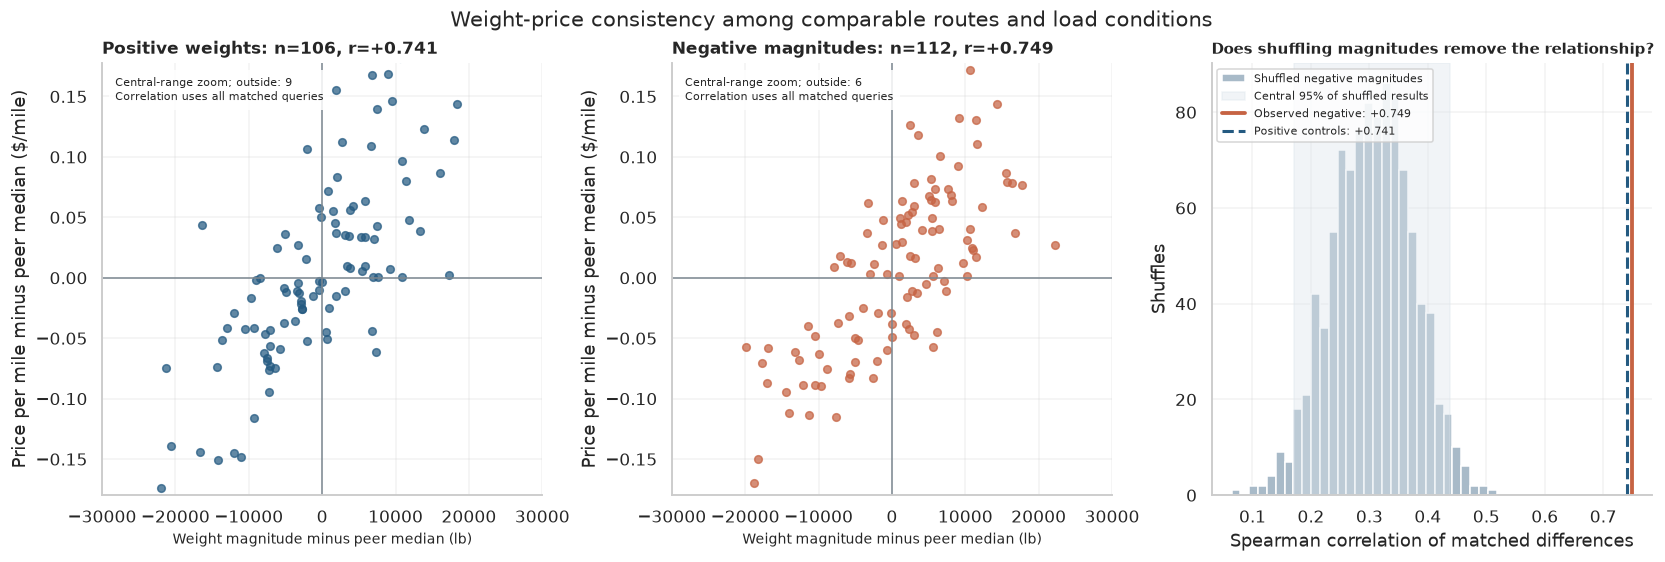

**Observed matched relationship:** negative magnitudes **+0.749**, positive controls **+0.741**. The central 95% of **1,000 shuffled-weight** correlations is **+0.171 to +0.438**.

Scatter panels zoom to the pooled 5th-95th percentile price-difference range plus padding; points outside the view are counted and retained in every statistic. Shuffling preserves equipment/month groups and the matching baselines but breaks each query's original weight assignment. This is a diagnostic reference for unrelated assignments within those groups, not proof of a particular error mechanism or a confidence interval for future prediction performance.

In [19]:
# Reference: shuffle negative magnitudes within equipment/month, never prices or matched peers.
# Matching did not use weight, so peer selection remains fixed under this diagnostic.
wr_matched_negative = wr_matched.loc[wr_matched["Group"].eq("Negative magnitudes")]
wr_permutation_count = 1000
wr_permutation_rng = np.random.default_rng(20261004)
wr_all_negative = wr_negative.reset_index(drop=True)
wr_permuted_weights = np.tile(
    wr_all_negative["weight_magnitude"].to_numpy(), (wr_permutation_count, 1)
)
for _, indices in wr_all_negative.groupby(["equipment", "calendar_month"]).indices.items():
    values = np.tile(wr_all_negative.iloc[indices]["weight_magnitude"].to_numpy(),
                     (wr_permutation_count, 1))
    wr_permuted_weights[:, indices] = wr_permutation_rng.permuted(values, axis=1)
wr_negative_positions = pd.Series(
    np.arange(len(wr_all_negative)), index=wr_all_negative["load_id"]
).loc[wr_matched_negative["load_id"]].to_numpy()
wr_shuffled_differences = (
    wr_permuted_weights[:, wr_negative_positions]
    - wr_matched_negative["Peer median weight"].to_numpy()[None, :]
)
wr_fixed_price_differences = np.tile(
    wr_matched_negative["Price difference"].to_numpy(), (wr_permutation_count, 1)
)
wr_shuffled_correlations = wr_row_spearman(wr_shuffled_differences, wr_fixed_price_differences)
wr_reference_low, wr_reference_high = np.quantile(wr_shuffled_correlations, [0.025, 0.975])
wr_negative_r = wr_matched_summary.loc["Negative magnitudes", "Weight/price difference correlation"]
wr_positive_r = wr_matched_summary.loc["Positive weights", "Weight/price difference correlation"]

wr_fig, wr_axes = plt.subplots(1, 3, figsize=(15, 5))
wr_delta_low, wr_delta_high = wr_matched["Price difference"].quantile([0.05, 0.95])
wr_delta_padding = max((wr_delta_high - wr_delta_low) * 0.08, 0.03)
for ax, group_name in zip(wr_axes[:2], ["Positive weights", "Negative magnitudes"]):
    subset = wr_matched.loc[wr_matched["Group"].eq(group_name)]
    corr = wr_matched_summary.loc[group_name, "Weight/price difference correlation"]
    ax.axhline(0, color="#7B8790", linewidth=1)
    ax.axvline(0, color="#7B8790", linewidth=1)
    ax.scatter(subset["Weight difference"], subset["Price difference"],
                s=25, alpha=0.72, color=wr_colors[group_name])
    ax.set_title(f"{group_name}: n={len(subset)}, r={corr:+.3f}", fontsize=11)
    ax.set_xlabel("Weight magnitude minus peer median (lb)", fontsize=9)
    ax.set_ylim(wr_delta_low - wr_delta_padding, wr_delta_high + wr_delta_padding)
    ax.set_xlim(-30000, 30000)
    outside = (
        ~subset["Price difference"].between(wr_delta_low - wr_delta_padding, wr_delta_high + wr_delta_padding)
        | ~subset["Weight difference"].between(-30000, 30000)
    ).sum()
    ax.text(0.03, 0.97, f"Central-range zoom; outside: {outside}\nCorrelation uses all matched queries",
             transform=ax.transAxes, va="top", fontsize=7.5,
             bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"})
wr_axes[0].set_ylabel("Price per mile minus peer median ($/mile)")
wr_axes[1].set_ylabel("Price per mile minus peer median ($/mile)")
wr_axes[2].hist(wr_shuffled_correlations, bins=30, color="#A8BAC8", edgecolor="white",
                label="Shuffled negative magnitudes")
wr_axes[2].axvspan(wr_reference_low, wr_reference_high, color="#DDE5EC", alpha=0.4,
                   label="Central 95% of shuffled results")
wr_axes[2].axvline(wr_negative_r, color=wr_colors["Negative magnitudes"], linewidth=2.5,
                   label=f"Observed negative: {wr_negative_r:+.3f}")
wr_axes[2].axvline(wr_positive_r, color=wr_colors["Positive weights"], linewidth=2, linestyle="--",
                   label=f"Positive controls: {wr_positive_r:+.3f}")
wr_axes[2].set_title("Does shuffling magnitudes remove the relationship?", fontsize=10)
wr_axes[2].set_xlabel("Spearman correlation of matched differences")
wr_axes[2].set_ylabel("Shuffles")
wr_axes[2].legend(fontsize=7.5, loc="upper left")
wr_fig.suptitle("Weight-price consistency among comparable routes and load conditions", fontsize=14)
wr_fig.savefig(wr_output_dir / "negative_weight_matched_relationships.png", dpi=150,
               bbox_inches="tight", facecolor="white")
plt.show()
plt.close(wr_fig)
display(Markdown(
    f"**Observed matched relationship:** negative magnitudes **{wr_negative_r:+.3f}**, "
    f"positive controls **{wr_positive_r:+.3f}**. "
    f"The central 95% of **{wr_permutation_count:,} shuffled-weight** correlations is "
    f"**{wr_reference_low:+.3f} to {wr_reference_high:+.3f}**.\n\n"
    "Scatter panels zoom to the pooled 5th-95th percentile price-difference range plus padding; "
    "points outside the view are counted and retained in every statistic. "
    "Shuffling preserves equipment/month groups and the matching baselines but breaks each query's original "
    "weight assignment. This is a diagnostic reference for unrelated assignments within those groups, "
    "not proof of a particular error mechanism or a confidence interval for future prediction performance."
))

In [20]:
wr_covered = int(wr_matched_summary.loc["Negative magnitudes", "Matched queries"])
wr_coverage = wr_matched_summary.loc["Negative magnitudes", "Coverage (%)"]
display(Markdown(f"""
**Revised conclusion based on relationships**

- The marginal median comparison in section 5b is insufficient to establish a sign-entry error.
- Pooled development correlations between weight magnitude and price per mile are **{wr_correlation_table.query("Dataset == 'Development' and Attribute == 'Posted price per mile'")["Positive correlation"].iloc[0]:+.3f}** for positive weights and **{wr_correlation_table.query("Dataset == 'Development' and Attribute == 'Posted price per mile'")["Negative-magnitude correlation"].iloc[0]:+.3f}** for negative weights.
- Within equipment, the associations are similar for Dry Van and Reefer; the negative Flatbed association is weaker. The smaller negative groups carry substantial uncertainty.
- After matching route, equipment, date, distance, and market conditions, weight and price differences show a **{wr_negative_r:+.3f}** rank correlation for negative magnitudes versus **{wr_positive_r:+.3f}** for positive controls. The shuffled-weight reference spans **{wr_reference_low:+.3f} to {wr_reference_high:+.3f}** for its central 95%.
- This is stronger evidence that negative magnitudes contain meaningful load-weight information, rather than merely sharing a similar distribution with positives. However, only **{wr_covered} of {len(wr_negative)} negative development loads ({wr_coverage:.1f}%)** met the matching requirements. Sparse peers, approximate matching, shared reference loads, and unmatched confounding limit the conclusion.
- The final-input file has no price labels, so we cannot confirm its weight-price relationship. Relationships with its available attributes are shown separately.

**Adopted decision:** apply `abs(weight)` in the working DataFrames and retain `weight_was_negative`. Missing weights remain missing, and saved CSVs remain unchanged. Validate this selected assumption on chronological folds, including errors for originally negative loads; negative-as-missing can remain an optional sensitivity benchmark. The diagnostic uses original signed records and does not establish the source of the error.
"""))


**Revised conclusion based on relationships**

- The marginal median comparison in section 5b is insufficient to establish a sign-entry error.
- Pooled development correlations between weight magnitude and price per mile are **+0.199** for positive weights and **+0.152** for negative weights.
- Within equipment, the associations are similar for Dry Van and Reefer; the negative Flatbed association is weaker. The smaller negative groups carry substantial uncertainty.
- After matching route, equipment, date, distance, and market conditions, weight and price differences show a **+0.749** rank correlation for negative magnitudes versus **+0.741** for positive controls. The shuffled-weight reference spans **+0.171 to +0.438** for its central 95%.
- This is stronger evidence that negative magnitudes contain meaningful load-weight information, rather than merely sharing a similar distribution with positives. However, only **112 of 292 negative development loads (38.4%)** met the matching requirements. Sparse peers, approximate matching, shared reference loads, and unmatched confounding limit the conclusion.
- The final-input file has no price labels, so we cannot confirm its weight-price relationship. Relationships with its available attributes are shown separately.

**Adopted decision:** apply `abs(weight)` in the working DataFrames and retain `weight_was_negative`. Missing weights remain missing, and saved CSVs remain unchanged. Validate this selected assumption on chronological folds, including errors for originally negative loads; negative-as-missing can remain an optional sensitivity benchmark. The diagnostic uses original signed records and does not establish the source of the error.


## 6. Time coverage and changes over time

The dates separate the files naturally: labeled development observations come before the final prediction period. Monthly counts describe sample coverage; monthly median prices can also change because the mix of routes or equipment changes.

There are no labeled November or December observations. This dataset alone cannot demonstrate a recurring December seasonal pattern.

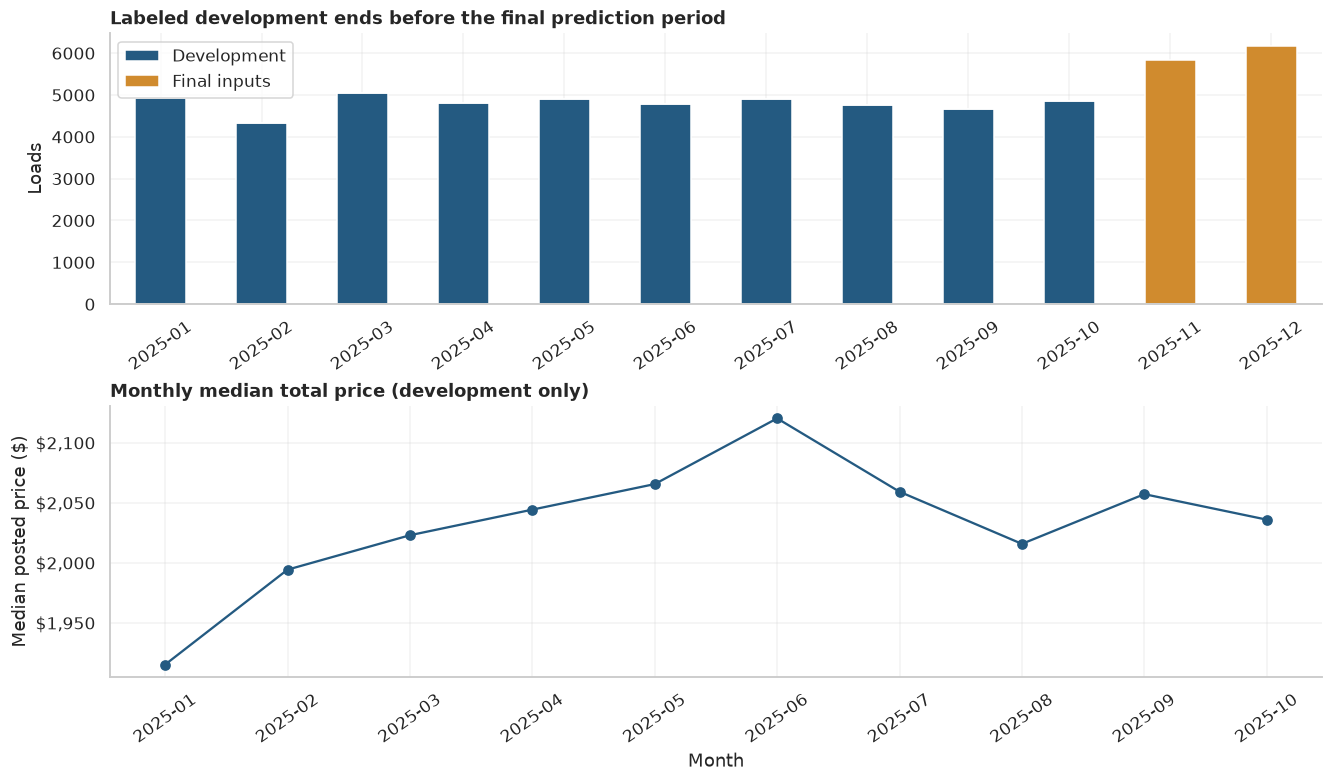

,loads,median_price,median_rpm
month,,,
2025-01,4918,"1,915.200",2.029
2025-02,4337,"1,994.250",2.061
2025-03,5036,"2,022.920",2.139
2025-04,4819,"2,044.240",2.147
2025-05,4913,"2,065.510",2.190
2025-06,4783,"2,120.220",2.248
2025-07,4912,"2,059.145",2.187
2025-08,4759,"2,015.730",2.121
2025-09,4670,"2,057.130",2.160


In [21]:
monthly_dev = dev.groupby("month").agg(
    loads=("load_id", "size"), median_price=("posted_rate", "median"),
    median_rpm=("rate_per_mile", "median"),
)
monthly_future = future.groupby("month").agg(loads=("load_id", "size"))
month_order = sorted(set(monthly_dev.index) | set(monthly_future.index))
counts = pd.DataFrame({
    "Development": monthly_dev["loads"],
    "Final inputs": monthly_future["loads"],
}).reindex(month_order).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
counts.plot.bar(stacked=True, color=[COLORS[column] for column in counts.columns], ax=axes[0])
axes[0].set_title("Labeled development ends before the final prediction period")
axes[0].set_xlabel("")
axes[0].set_ylabel("Loads")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="")

axes[1].plot(monthly_dev.index, monthly_dev["median_price"],
             marker="o", color=COLORS["Development"])
axes[1].set_title("Monthly median total price (development only)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Median posted price ($)")
axes[1].yaxis.set_major_formatter(dollars)
axes[1].tick_params(axis="x", rotation=35)
plt.show()
display(monthly_dev.round(3))

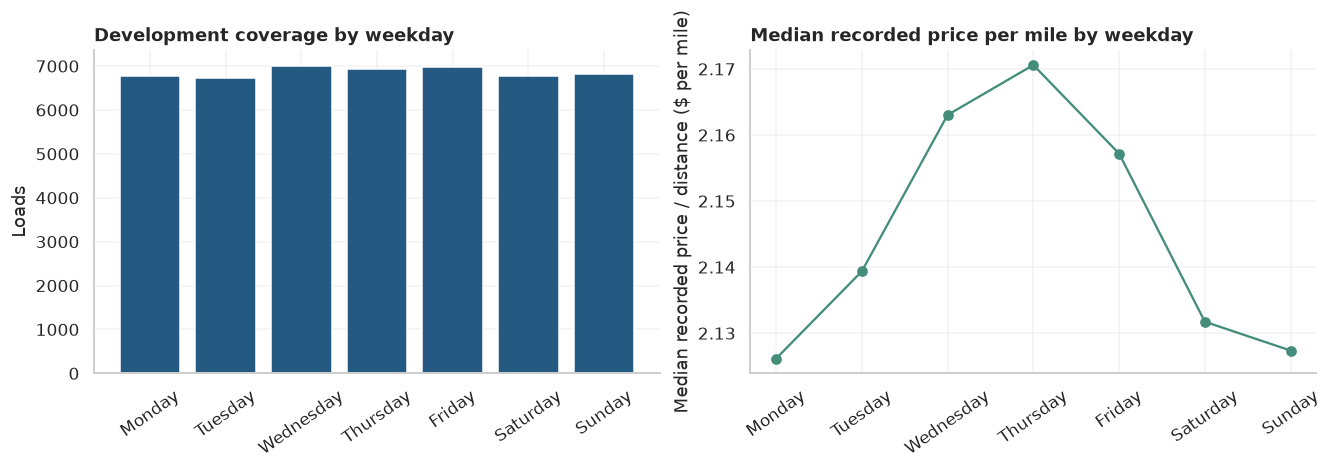

These weekday summaries are not adjusted for route, equipment, or time trends. A visible difference is a candidate relationship to validate, not an established pricing rule.

In [22]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = dev.groupby("weekday").agg(
    loads=("load_id", "size"),
    median_rpm=("rate_per_mile", "median"),
).reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(weekday_summary.index, weekday_summary["loads"], color=COLORS["Development"])
axes[0].set_title("Development coverage by weekday")
axes[0].set_ylabel("Loads")
axes[1].plot(weekday_summary.index, weekday_summary["median_rpm"],
             marker="o", color="#438D7A")
axes[1].set_title("Median recorded price per mile by weekday")
axes[1].set_ylabel("Median recorded price / distance ($ per mile)")
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")
plt.show()
display(Markdown(
    "These weekday summaries are not adjusted for route, equipment, or time trends. "
    "A visible difference is a candidate relationship to validate, not an established pricing rule."
))

## 7. Geography, lanes, and unseen cities

A **lane** is a pickup–delivery pair. Location matters beyond distance, and the reverse lane can behave differently.

The coordinate scatter below shows the dataset's supplied city coordinates without a geographic basemap. It is **not** a verified map of real city locations. New-city counts are based on city names, not coordinate proximity.

,Measure,Value
0,Development cities,64
1,Final-input cities,72
2,Previously unseen city names,8
3,Final rows involving an unseen city,1447
4,Final rows on an unseen directional lane,1461


**Unseen city names:** Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego

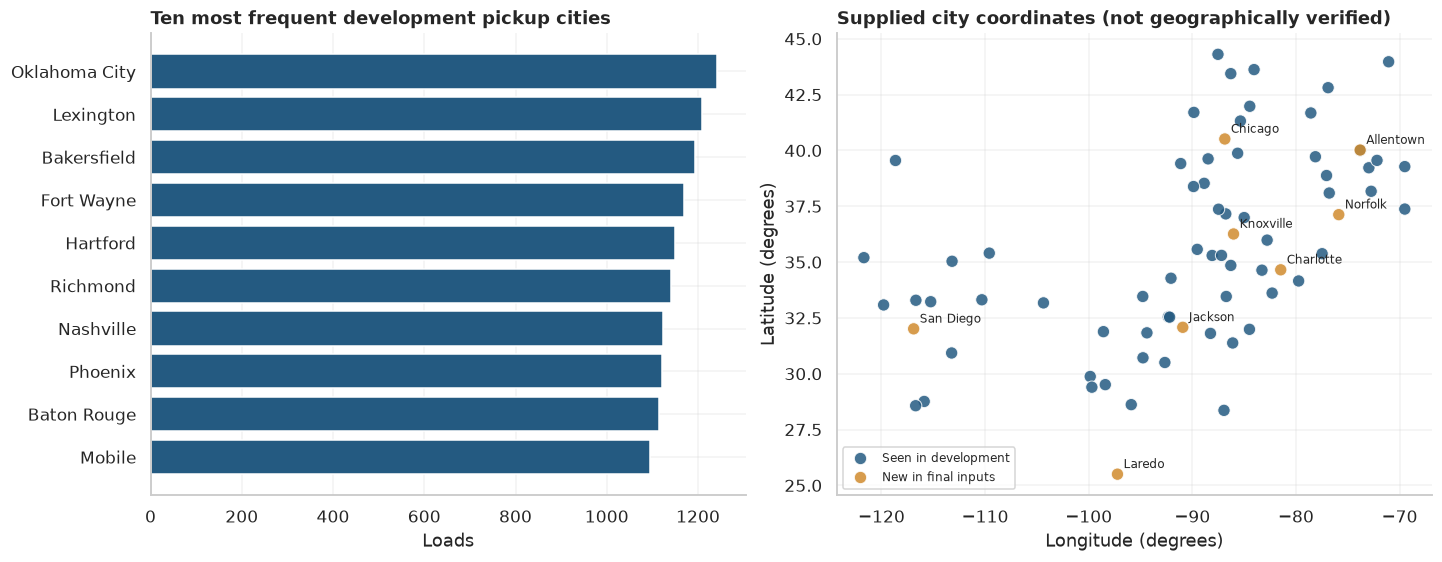

loads  median_distance  median_price
pickup     delivery                                           
Columbia   Oklahoma City     39        1,058.900     2,327.430
Phoenix    Shreveport        39        1,669.000     3,554.430
Lexington  Atlanta           39          209.100       553.630
Fort Wayne Philadelphia      38          792.350     1,708.835
Shreveport Hartford          37        1,436.500     2,812.520
Fort Wayne Hartford          37          831.300     1,725.990
Richmond   Oklahoma City     37        1,526.200     3,126.490
           Phoenix           37        2,710.600     5,010.880
Lexington  Kansas City       37          448.600     1,029.800
           Cincinnati        37          132.200       377.100

In [23]:
known_cities = set(dev["pickup"]) | set(dev["delivery"])
final_cities = set(future["pickup"]) | set(future["delivery"])
unseen_cities = sorted(final_cities - known_cities)
new_city_rows = (~future["pickup"].isin(known_cities)) | (~future["delivery"].isin(known_cities))
known_lanes = set(zip(dev["pickup"], dev["delivery"]))
final_lane_pairs = list(zip(future["pickup"], future["delivery"]))
new_lane_rows = np.array([lane not in known_lanes for lane in final_lane_pairs])

display(pd.DataFrame({
    "Measure": ["Development cities", "Final-input cities", "Previously unseen city names",
                "Final rows involving an unseen city", "Final rows on an unseen directional lane"],
    "Value": [len(known_cities), len(final_cities), len(unseen_cities),
              int(new_city_rows.sum()), int(new_lane_rows.sum())],
}))
display(Markdown("**Unseen city names:** " + ", ".join(unseen_cities)))

cities = pd.concat([
    future[["pickup", "pickup_lat", "pickup_lon"]].rename(
        columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"}),
    future[["delivery", "delivery_lat", "delivery_lon"]].rename(
        columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"}),
]).drop_duplicates()
cities["City status"] = np.where(cities["city"].isin(known_cities), "Seen in development", "New in final inputs")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_origins = dev["pickup"].value_counts().head(10).sort_values()
axes[0].barh(top_origins.index, top_origins.values, color=COLORS["Development"])
axes[0].set_title("Ten most frequent development pickup cities")
axes[0].set_xlabel("Loads")
sns.scatterplot(data=cities, x="lon", y="lat", hue="City status",
                palette={"Seen in development": "#245A81", "New in final inputs": "#D08B2E"},
                s=65, alpha=0.85, ax=axes[1])
for row in cities[cities["city"].isin(unseen_cities)].itertuples():
    axes[1].annotate(row.city, (row.lon, row.lat), xytext=(4, 4),
                     textcoords="offset points", fontsize=8)
axes[1].set_title("Supplied city coordinates (not geographically verified)")
axes[1].set_xlabel("Longitude (degrees)")
axes[1].set_ylabel("Latitude (degrees)")
axes[1].legend(title="", fontsize=8, loc="lower left")
plt.show()

lane_summary = dev.groupby(["pickup", "delivery"], observed=True).agg(
    loads=("load_id", "size"), median_distance=("distance", "median"),
    median_price=("posted_rate", "median"),
).sort_values("loads", ascending=False)
display(lane_summary.head(10))

## 8. Compare development and final-input distributions

The following charts compare **available features**, not target accuracy. The final target is hidden.

Each histogram is independently normalized so that its area is one. This makes shapes comparable even though the row counts differ. Corrected positive weights are used, including originally negative records. Missing weights remain excluded from the weight histogram.

Distribution changes may reflect time, new cities, or different shipment mixes. They do not by themselves establish why the change occurred.

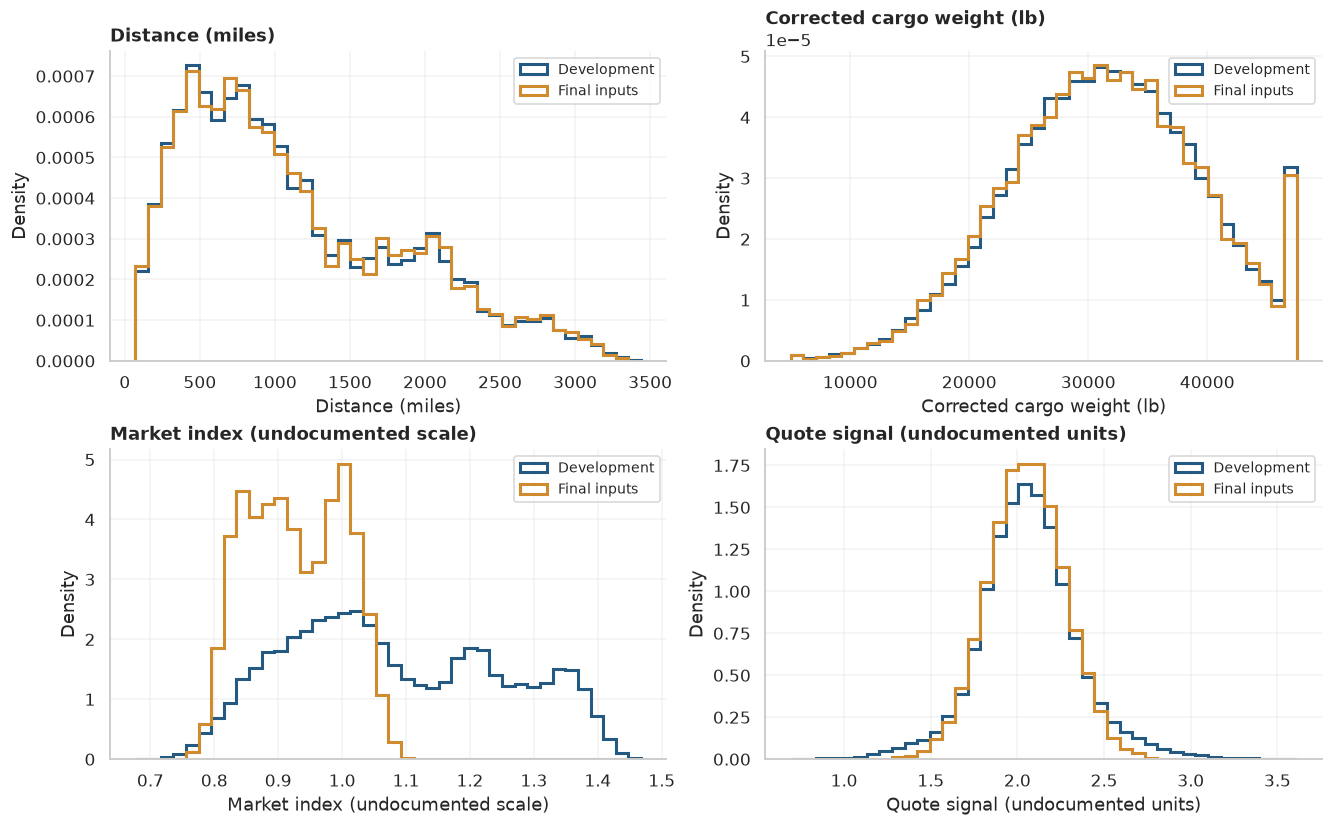

,Development (%),Final inputs (%)
equipment,,
Dry Van,56.670,56.500
Reefer,25.090,25.420
Flatbed,18.240,18.080


In [24]:
comparison_features = [
    ("distance", "Distance (miles)"),
    ("weight_valid", "Corrected cargo weight (lb)"),
    ("market_index", "Market index (undocumented scale)"),
    ("quote_signal", "Quote signal (undocumented units)"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 7.4))
for ax, (column, label) in zip(axes.flat, comparison_features):
    pooled = pd.concat([dev[column], future[column]]).dropna()
    bin_edges = np.histogram_bin_edges(pooled, bins=40)
    for name, frame in {"Development": dev, "Final inputs": future}.items():
        ax.hist(frame[column].dropna(), bins=bin_edges, density=True,
                histtype="step", linewidth=2, label=name, color=COLORS[name])
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(title="", fontsize=9)
plt.show()

equipment_mix = pd.DataFrame({
    "Development (%)": dev["equipment"].value_counts(normalize=True).mul(100),
    "Final inputs (%)": future["equipment"].value_counts(normalize=True).mul(100),
}).reindex(equipment_order)
display(equipment_mix.round(2))

## 9. Relationships between numerical columns

Spearman correlation compares ranks. It can reveal a consistently increasing or decreasing relationship without assuming a straight line.

- Values near **+1**: the two columns tend to increase together.
- Values near **−1**: one tends to decrease when the other increases.
- Values near **0**: little monotonic relationship in the pooled data; nonlinear or time-specific relationships may still exist.

Correlations are calculated from development data only, using available pairs. Weight-related pairs use corrected positive weights; missing weights remain excluded. Correlation does not establish causality, feature importance, or whether a signal leaks target information.

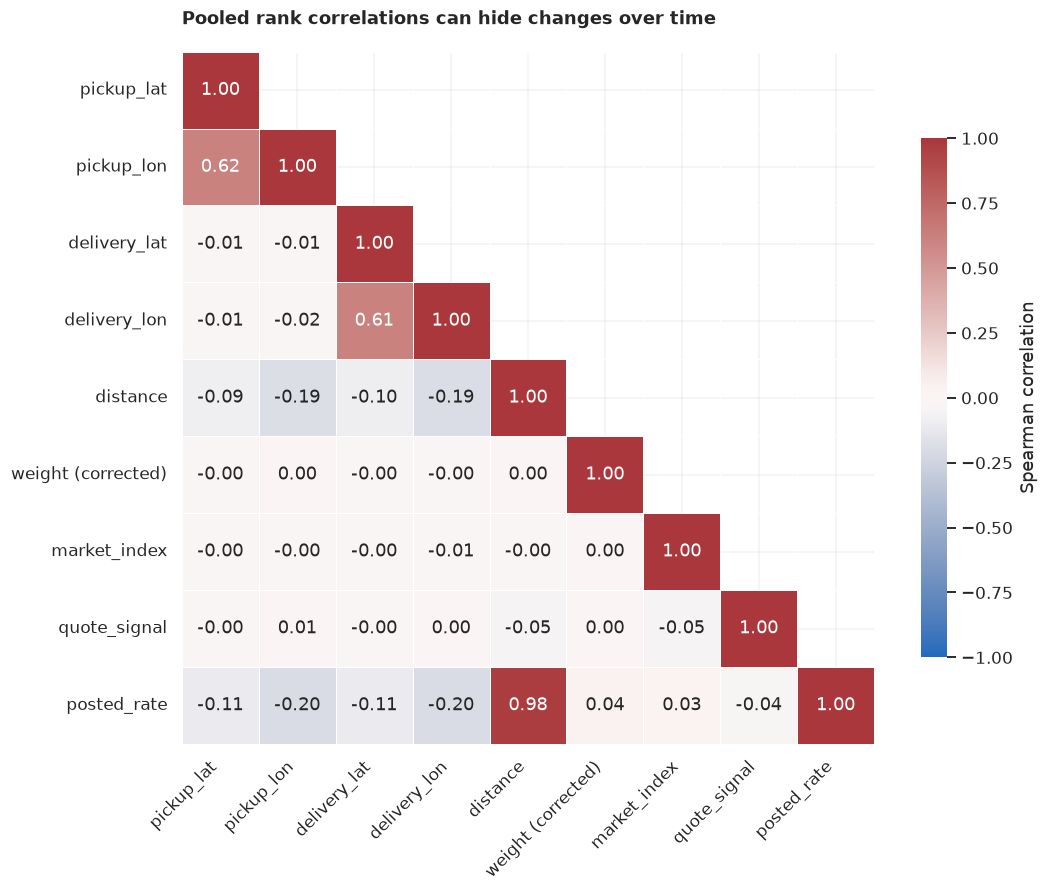

In [25]:
numeric_columns = [
    "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "distance", "weight_valid", "market_index", "quote_signal", "posted_rate",
]
spearman = dev[numeric_columns].corr(method="spearman").rename(
    index={"weight_valid": "weight (corrected)"}, columns={"weight_valid": "weight (corrected)"}
)
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(spearman, dtype=bool), k=1)
sns.heatmap(spearman, mask=mask, annot=True, fmt=".2f", cmap="vlag",
             vmin=-1, vmax=1, center=0, square=True, linewidths=0.6,
             cbar_kws={"label": "Spearman correlation", "shrink": 0.75}, ax=ax)
ax.set_title("Pooled rank correlations can hide changes over time", pad=18)
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.show()

## 10. Check whether the quote and market signals are stable

A signal can look weak when all months are combined but have a strong, changing relationship within individual months.

Here, compare each signal with **recorded price per mile**, so trip length does not dominate the comparison. This does not establish the units of `quote_signal`; its construction remains undocumented.

All valid observations contribute to the monthly correlations. These diagnostics can motivate time-based validation and feature checks, but cannot establish how the signals were generated or prove target leakage.

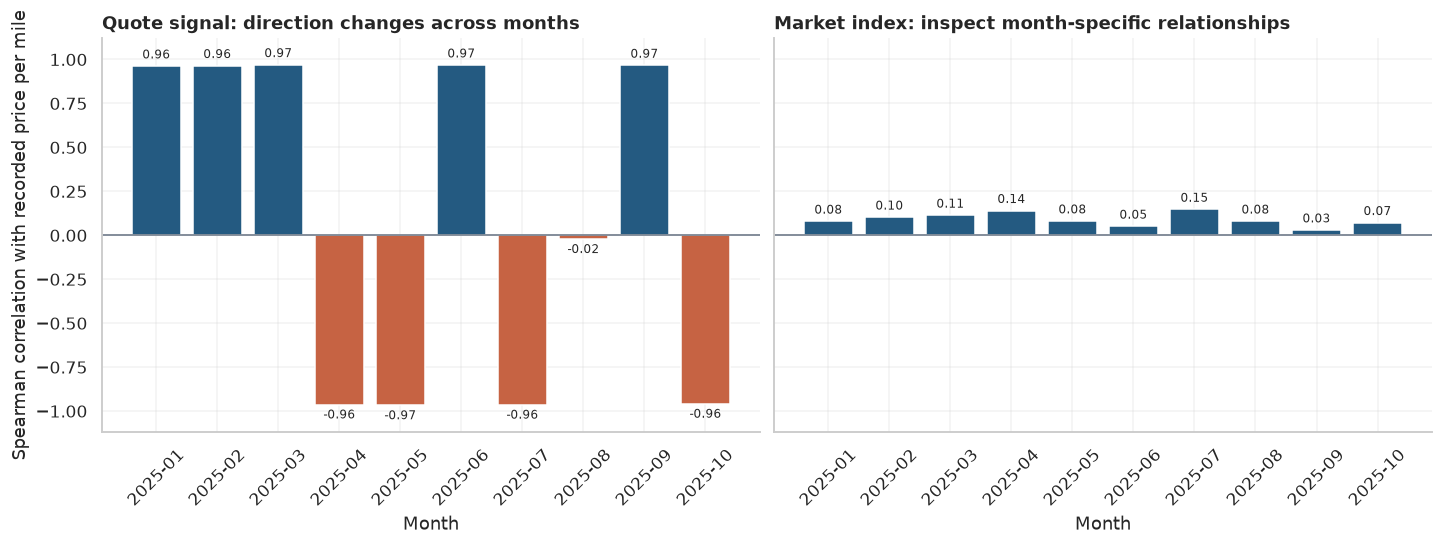

,Loads,Quote vs price/mile,Market vs price/mile,Available market pairs
Month,,,,
2025-01,4918,0.963,0.080,4882
2025-02,4337,0.965,0.103,4301
2025-03,5036,0.970,0.114,4992
2025-04,4819,-0.963,0.140,4788
2025-05,4913,-0.968,0.081,4870
2025-06,4783,0.968,0.051,4741
2025-07,4912,-0.965,0.147,4876
2025-08,4759,-0.022,0.080,4726
2025-09,4670,0.967,0.030,4639


**Strong positive quote relationship:** 2025-01, 2025-02, 2025-03, 2025-06, 2025-09.

**Strong negative quote relationship:** 2025-04, 2025-05, 2025-07, 2025-10.

**Weak monotonic quote relationship:** 2025-08.

A single pooled correlation would miss this instability. Later validation should compare performance with and without this signal on genuinely later dates.

In [26]:
signal_rows = []
for month, group in dev.groupby("month", sort=True):
    signal_rows.append({
        "Month": month,
        "Loads": len(group),
        "Quote vs price/mile": group[["quote_signal", "rate_per_mile"]].corr(
            method="spearman").loc["quote_signal", "rate_per_mile"],
        "Market vs price/mile": group[["market_index", "rate_per_mile"]].corr(
            method="spearman").loc["market_index", "rate_per_mile"],
        "Available market pairs": int(group[["market_index", "rate_per_mile"]].notna().all(axis=1).sum()),
    })
signal_by_month = pd.DataFrame(signal_rows).set_index("Month")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, column, title in [
    (axes[0], "Quote vs price/mile", "Quote signal: direction changes across months"),
    (axes[1], "Market vs price/mile", "Market index: inspect month-specific relationships"),
]:
    values = signal_by_month[column]
    ax.bar(values.index, values.values,
            color=["#245A81" if value >= 0 else "#C66343" for value in values])
    ax.axhline(0, color="#657181", linewidth=1)
    ax.set_ylim(-1.12, 1.12)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=45)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
axes[0].set_ylabel("Spearman correlation with recorded price per mile")
plt.show()
display(signal_by_month.round(3))

positive_months = signal_by_month.index[signal_by_month["Quote vs price/mile"].gt(0.8)].tolist()
negative_months = signal_by_month.index[signal_by_month["Quote vs price/mile"].lt(-0.8)].tolist()
weak_months = signal_by_month.index[signal_by_month["Quote vs price/mile"].abs().lt(0.2)].tolist()
display(Markdown(
    f"**Strong positive quote relationship:** {', '.join(positive_months) or 'none'}.\n\n"
    f"**Strong negative quote relationship:** {', '.join(negative_months) or 'none'}.\n\n"
    f"**Weak monotonic quote relationship:** {', '.join(weak_months) or 'none'}.\n\n"
    "A single pooled correlation would miss this instability. Later validation should compare "
    "performance with and without this signal on genuinely later dates."
))

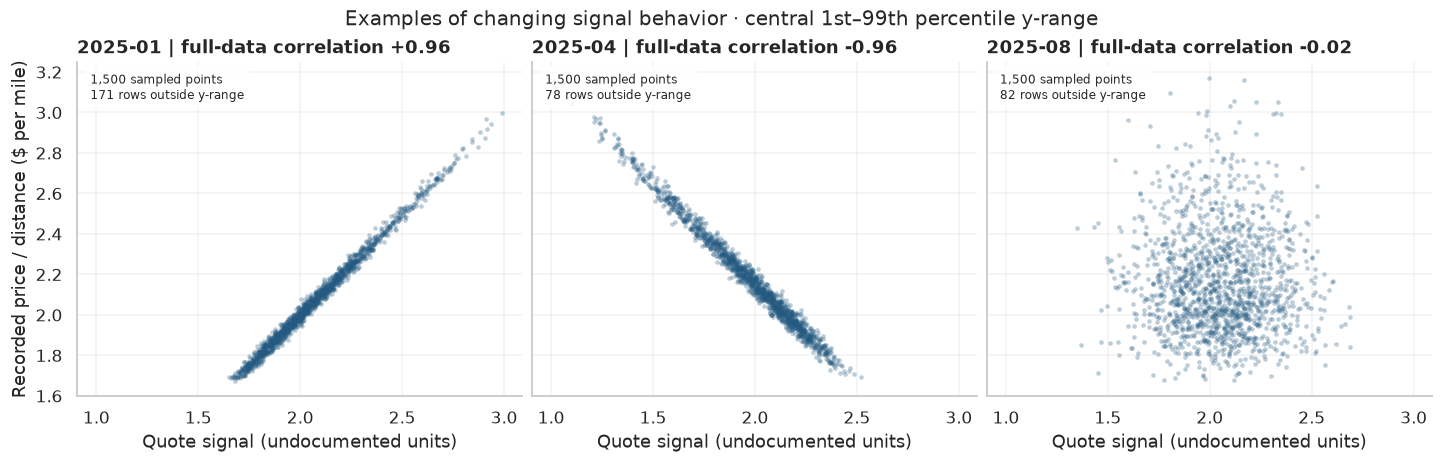

In [27]:
# A display-only zoom makes representative months readable.
rpm_low, rpm_high = dev["rate_per_mile"].quantile([0.01, 0.99])
illustrative_months = ["2025-01", "2025-04", "2025-08"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.1), sharex=True, sharey=True)
for ax, month in zip(axes, illustrative_months):
    month_rows = dev[dev["month"].eq(month)]
    visible = month_rows[month_rows["rate_per_mile"].between(rpm_low, rpm_high)]
    plotted = visible.sample(n=min(1500, len(visible)), random_state=SEED)
    ax.scatter(plotted["quote_signal"], plotted["rate_per_mile"],
                s=9, alpha=0.3, color=COLORS["Development"], linewidths=0)
    corr = signal_by_month.loc[month, "Quote vs price/mile"]
    omitted = len(month_rows) - len(visible)
    ax.set_title(f"{month} | full-data correlation {corr:+.2f}")
    ax.set_xlabel("Quote signal (undocumented units)")
    ax.text(0.03, 0.97, f"{len(plotted):,} sampled points\n{omitted:,} rows outside y-range",
             transform=ax.transAxes, va="top", fontsize=8,
             bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"})
axes[0].set_ylabel("Recorded price / distance ($ per mile)")
fig.suptitle("Examples of changing signal behavior · central 1st–99th percentile y-range", fontsize=13)
plt.show()

## 11. The December scenario and a possible validation timeline

Different row counts are harmless: a model can predict one row, 31 rows, or 12,000 rows. The **feature definitions** must still match what it was trained to use.

The December file contains six input columns plus the empty output column. It holds pickup, delivery, distance, equipment, and weight constant while changing the date.

Possible later approaches include a model using the six common inputs, or a separately validated model for this reduced-input scenario. Dataset coordinates for these two cities can be looked up from development data, but that does not supply the missing market and quote signals.

The timeline below is **illustrative**, not an implemented split:
- January–August: train a candidate.
- September–October: evaluate on later labeled observations.
- November–December: generate the final predictions after choosing the approach.
- December: also generate the fixed-scenario chart.

Several forward-moving evaluation windows would help investigate the changing quote relationship.

,Input,Unique values
0,pickup,[Lexington]
1,delivery,[Fort Wayne]
2,distance,[360]
3,equipment,[Dry Van]
4,weight,[32000]


,date,predicted_rate
0,2025-12-01,NaN
1,2025-12-02,NaN
2,2025-12-03,NaN
3,2025-12-04,NaN
4,2025-12-05,NaN


December includes **31 daily rows**, from **2025-12-01** to **2025-12-31**. All **31 output cells are still empty**.

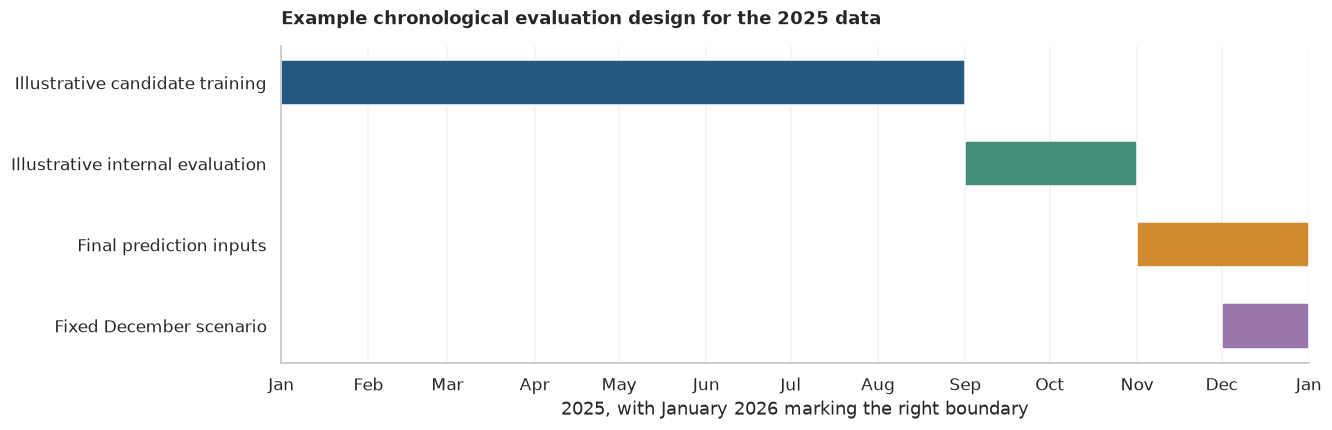

In [28]:
scenario_summary = pd.DataFrame({
    "Input": ["pickup", "delivery", "distance", "equipment", "weight"],
    "Unique values": [december[column].unique().tolist()
                      for column in ["pickup", "delivery", "distance", "equipment", "weight"]],
})
display(scenario_summary)
display(december[["date", "predicted_rate"]].head())
display(Markdown(
    f"December includes **{len(december):,} daily rows**, from "
    f"**{december['date'].min():%Y-%m-%d}** to **{december['date'].max():%Y-%m-%d}**. "
    f"All **{december['predicted_rate'].isna().sum():,} output cells are still empty**."
))

timeline = [
    ("Illustrative candidate training", "2025-01-01", "2025-09-01", "#245A81"),
    ("Illustrative internal evaluation", "2025-09-01", "2025-11-01", "#438D7A"),
    ("Final prediction inputs", "2025-11-01", "2026-01-01", "#D08B2E"),
    ("Fixed December scenario", "2025-12-01", "2026-01-01", "#9975AC"),
]
fig, ax = plt.subplots(figsize=(12, 3.8))
for row, (label, start, end, color) in enumerate(timeline):
    left = mdates.date2num(pd.Timestamp(start))
    width = mdates.date2num(pd.Timestamp(end)) - left
    ax.barh(row, width, left=left, color=color, height=0.56)
ax.set_yticks(range(len(timeline)), [row[0] for row in timeline])
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2026-01-01"))
ax.set_title("Example chronological evaluation design for the 2025 data", pad=14)
ax.set_xlabel("2025, with January 2026 marking the right boundary")
ax.grid(axis="y", visible=False)
plt.show()

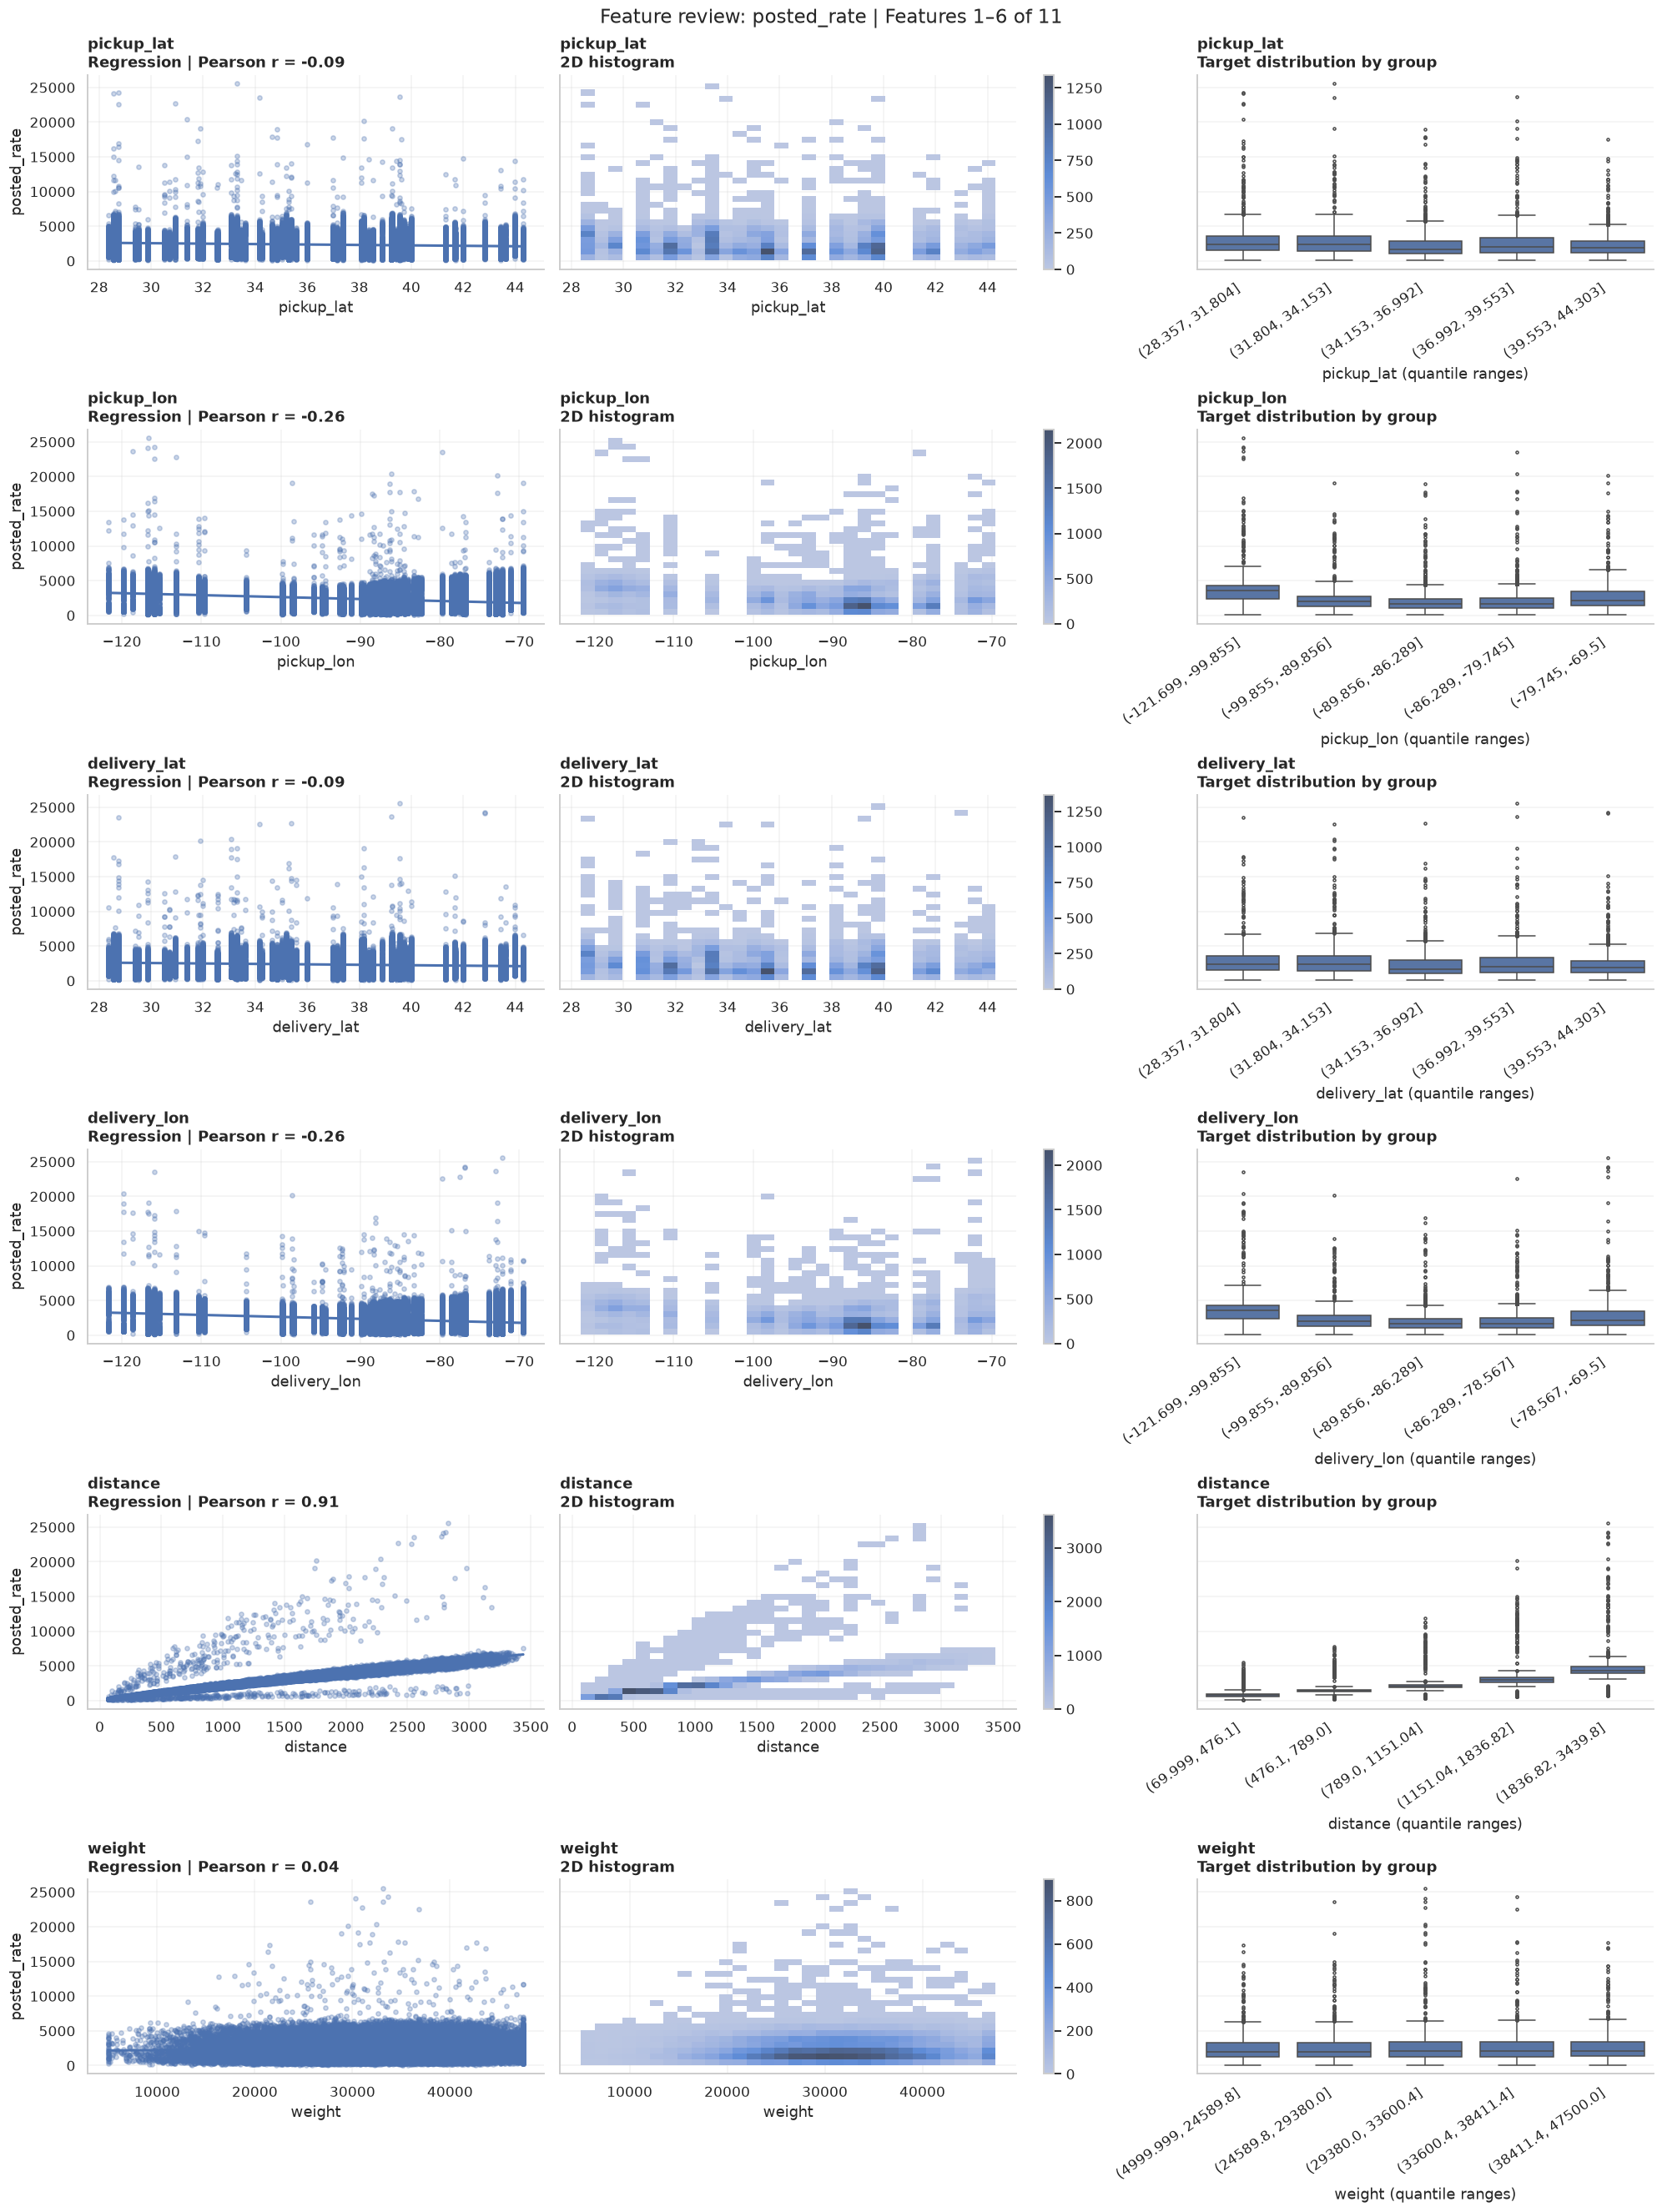

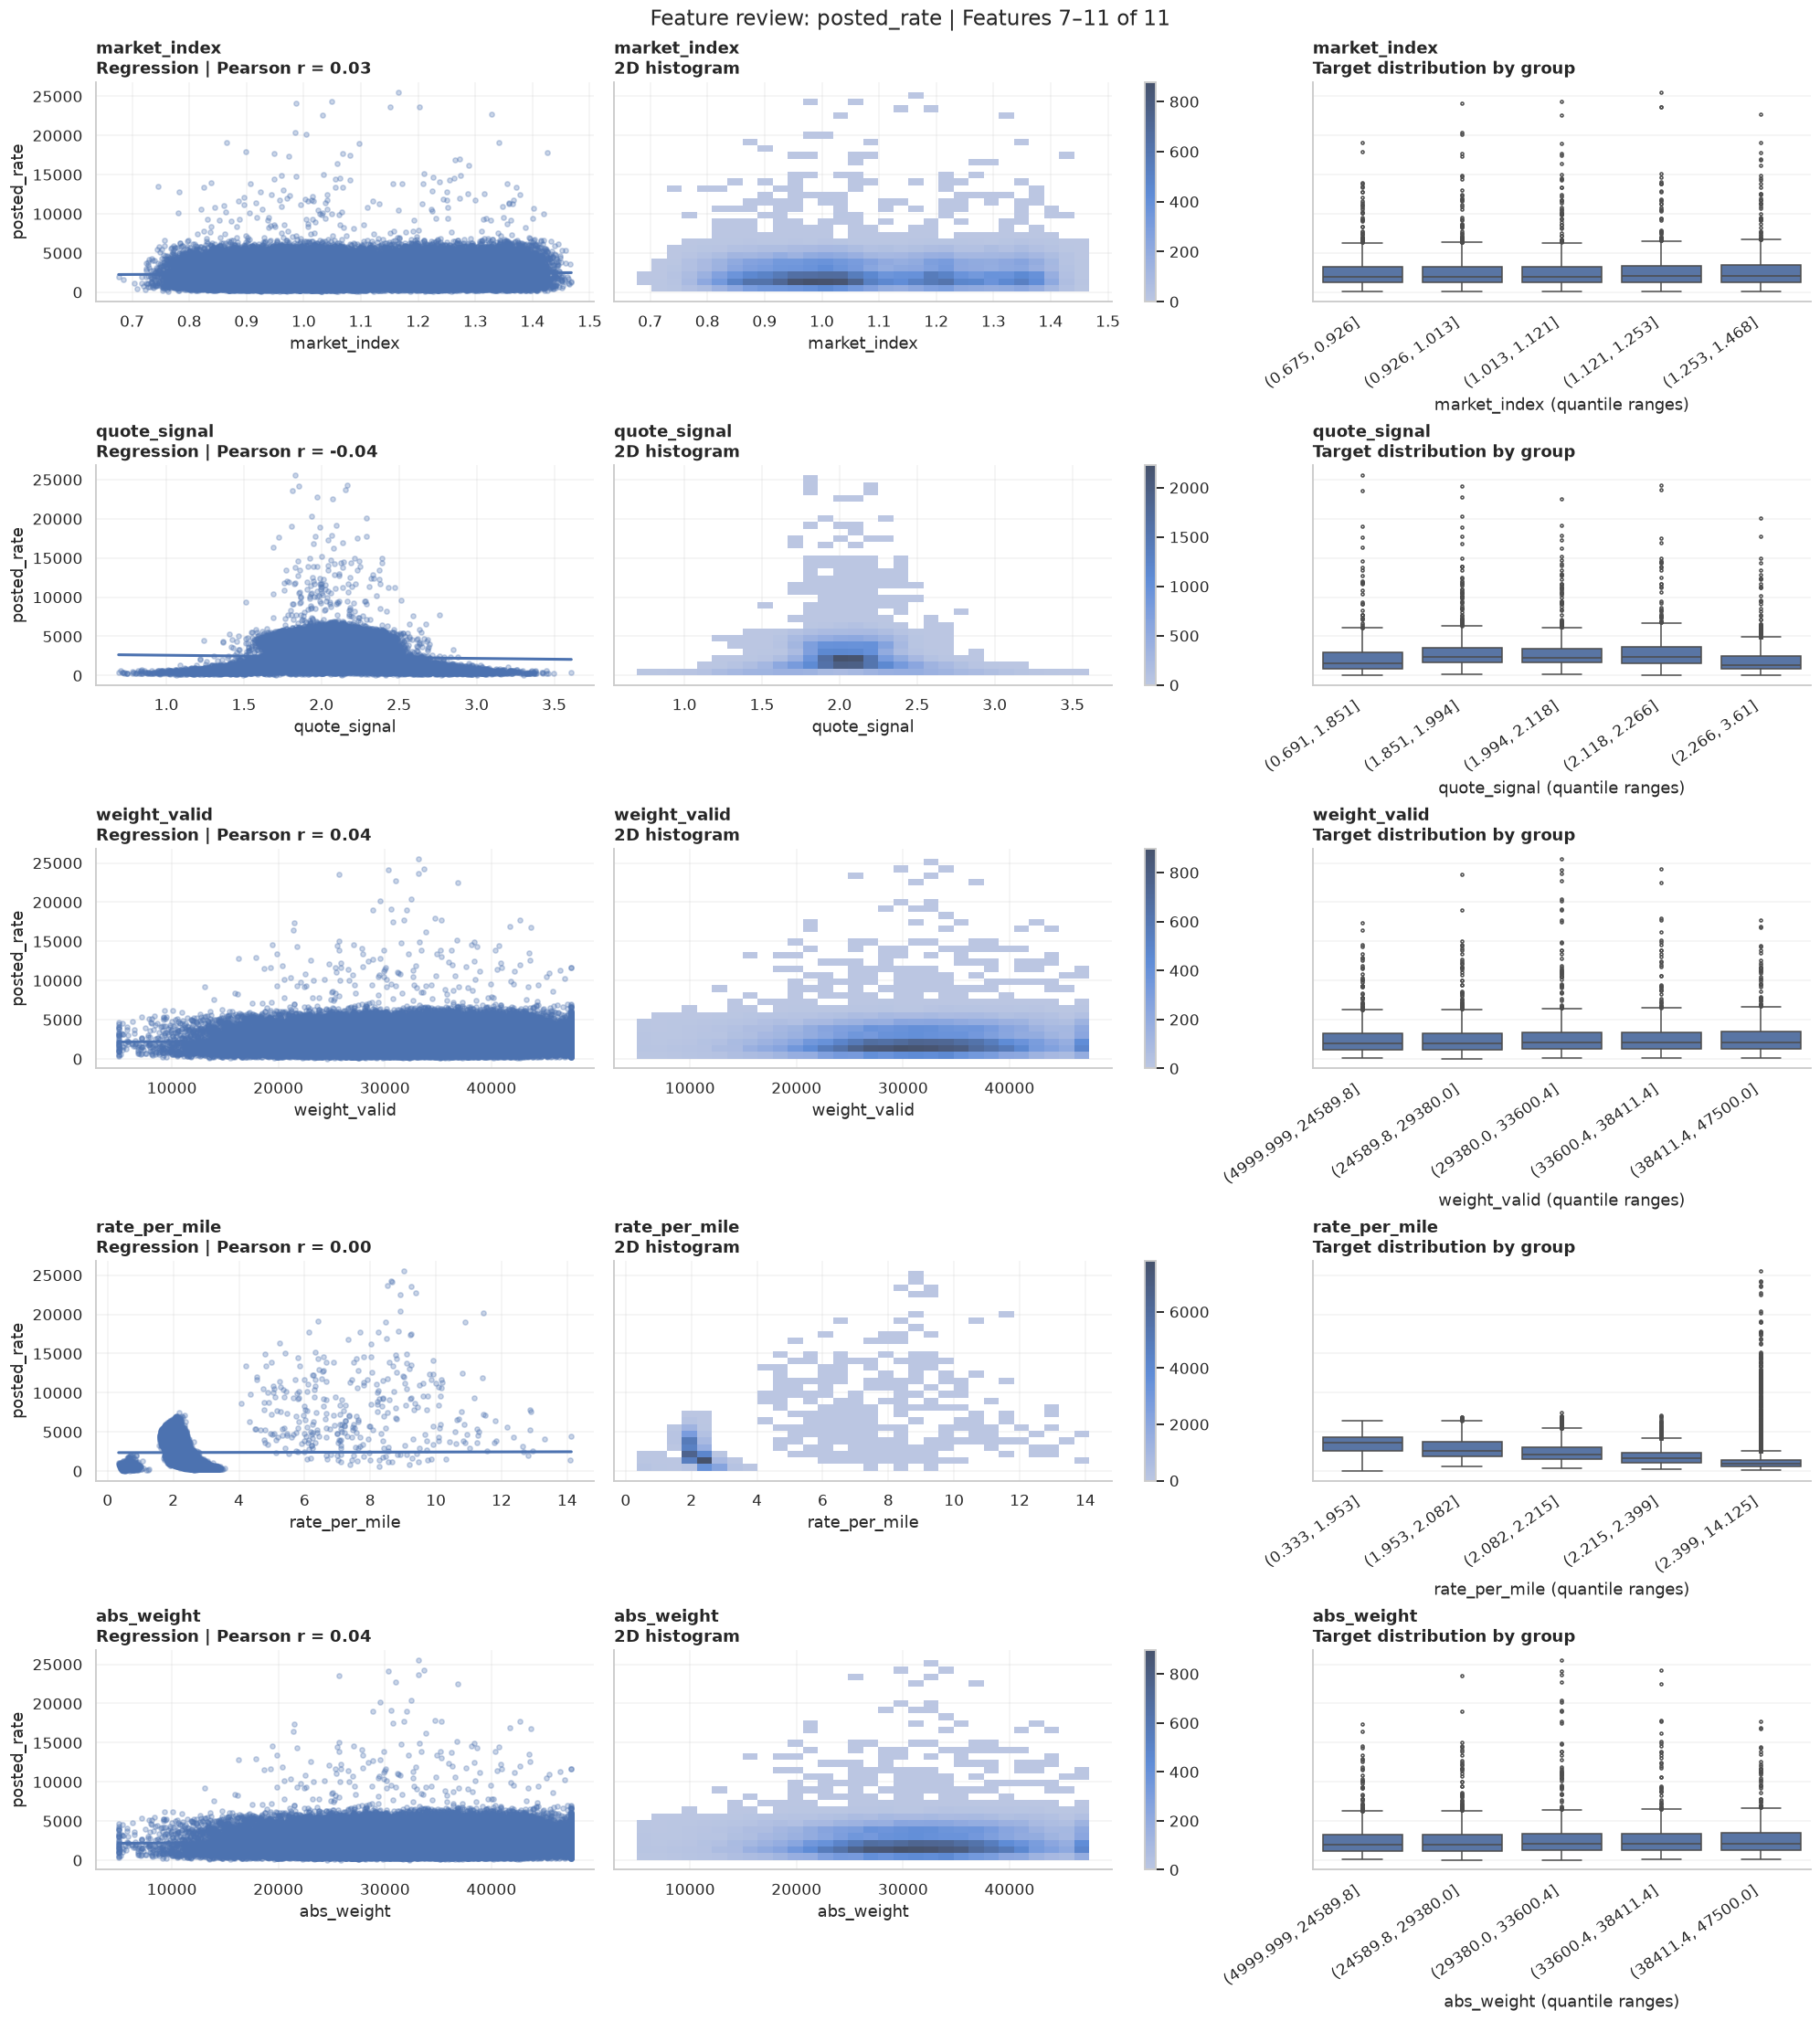

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target = "posted_rate"

# Controls figure size, NOT the total number of features plotted.
features_per_figure = 6  # Set to None to put all features in one figure.
n_bins = 5              # Number of ranges for continuous-feature boxplots.

if target not in dev.columns:
    raise ValueError(f"Target column {target!r} was not found.")

if not pd.api.types.is_numeric_dtype(dev[target]):
    raise TypeError(f"{target!r} must be numeric.")

# Include ALL numeric features, excluding the target.
selected_features = [
    col for col in dev.select_dtypes(include="number").columns
    if col != target
]

if not selected_features:
    print("No numeric feature columns are available.")
else:
    page_size = features_per_figure or len(selected_features)

    for start in range(0, len(selected_features), page_size):
        batch = selected_features[start:start + page_size]

        fig, axes = plt.subplots(
            nrows=len(batch),
            ncols=3,
            figsize=(18, 4 * len(batch)),
            squeeze=False,
            sharey="row",
        )

        for row, feature in enumerate(batch):
            ax_reg, ax_hist, ax_box = axes[row]

            # Clean each feature-target pair without modifying dev.
            data = (
                dev[[feature, target]]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .astype(float)
            )

            if len(data) < 2:
                for ax in axes[row]:
                    ax.text(
                        0.5,
                        0.5,
                        f"{feature}\nNot enough valid rows",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                    )
                    ax.set_axis_off()
                continue

            # --------------------------------------------------
            # 1. Scatter plot + linear regression
            # --------------------------------------------------
            feature_varies = data[feature].nunique() > 1

            sns.regplot(
                data=data,
                x=feature,
                y=target,
                ax=ax_reg,
                fit_reg=feature_varies,
                ci=None,
                scatter_kws={"alpha": 0.3, "s": 12},
                line_kws={"linewidth": 2},
            )

            # Correlation is undefined for a constant variable.
            r = (
                data[feature].corr(data[target])
                if feature_varies and data[target].nunique() > 1
                else np.nan
            )
            r_label = f"{r:.2f}" if np.isfinite(r) else "N/A"

            ax_reg.set_title(
                f"{feature}\nRegression | Pearson r = {r_label}"
            )

            # --------------------------------------------------
            # 2. 2D histogram: observation counts
            # --------------------------------------------------
            sns.histplot(
                data=data,
                x=feature,
                y=target,
                bins=30,
                cbar=True,
                ax=ax_hist,
            )
            ax_hist.set_title(f"{feature}\n2D histogram")

            # --------------------------------------------------
            # 3. Boxplots: target distribution by feature group
            # --------------------------------------------------
            if data[feature].nunique() <= 10:
                # Keep discrete values as separate groups.
                groups = data[feature]
                order = sorted(groups.unique())
                group_label = feature
            else:
                # Divide continuous values into quantile ranges.
                groups = pd.qcut(
                    data[feature],
                    q=n_bins,
                    duplicates="drop",
                )
                order = groups.cat.categories
                group_label = f"{feature} (quantile ranges)"

            sns.boxplot(
                x=groups,
                y=data[target],
                order=order,
                ax=ax_box,
                fliersize=2,
            )

            ax_box.set_title(f"{feature}\nTarget distribution by group")
            ax_box.set_xlabel(group_label)

            plt.setp(
                ax_box.get_xticklabels(),
                rotation=35,
                ha="right",
            )

            for ax in axes[row]:
                ax.set_ylabel(target)

        fig.suptitle(
            f"Feature review: {target} | "
            f"Features {start + 1}–{start + len(batch)} "
            f"of {len(selected_features)}",
            fontsize=15,
        )

        plt.show()
        plt.close(fig)

## 12. Findings and decisions for cycle 2

The summary below is calculated from the data above. These findings are descriptive; no model performance is claimed.

**Weight investigation (sections 5b-5c):** similar medians are insufficient. Section 5c compares relationships with other attributes, equipment-specific price patterns, and weight-price differences among comparable routes and load conditions. Absolute-value correction with `weight_was_negative` is now adopted in the working DataFrames. Missing weights and source CSVs remain unchanged. The cause remains unconfirmed, and later model validation should assess the selected assumption.

In [31]:
display(Markdown(f"""
- **Data coverage:** {len(dev):,} labeled development loads and {len(future):,} final-input loads, plus {len(december):,} fixed December scenarios.
- **Weight correction:** converted {dev['weight_was_negative'].sum():,} originally negative development weights and {future['weight_was_negative'].sum():,} final-input weights to positive values in memory. Missing weights remain missing: {dev['weight'].isna().sum():,} development and {future['weight'].isna().sum():,} final-input rows. Raw signed copies are retained for diagnostics.
- **Market data:** {dev['market_index'].isna().sum():,} development rows and {future['market_index'].isna().sum():,} final rows lack a market index.
- **Price range:** median total price is ${median_price:,.2f}; the maximum is ${dev['posted_rate'].max():,.2f}. Large observations need review rather than automatic removal.
- **New locations:** {len(unseen_cities)} city names occur only in the final inputs. {new_city_rows.sum():,} final rows ({new_city_rows.mean():.1%}) involve at least one of them.
- **Quote instability:** the monthly quote/price-per-mile rank correlation ranges from {signal_by_month['Quote vs price/mile'].min():+.3f} to {signal_by_month['Quote vs price/mile'].max():+.3f}. A random split may conceal the difficulty of predicting later periods.
- **December inputs:** only {len(common_features)} of the {len(feature_columns)} potential input features are directly supplied. A later prediction design must account for this.
"""))


- **Data coverage:** 48,000 labeled development loads and 12,000 final-input loads, plus 31 fixed December scenarios.
- **Weight correction:** converted 292 originally negative development weights and 145 final-input weights to positive values in memory. Missing weights remain missing: 300 development and 165 final-input rows. Raw signed copies are retained for diagnostics.
- **Market data:** 374 development rows and 249 final rows lack a market index.
- **Price range:** median total price is $2,030.76; the maximum is $25,533.00. Large observations need review rather than automatic removal.
- **New locations:** 8 city names occur only in the final inputs. 1,447 final rows (12.1%) involve at least one of them.
- **Quote instability:** the monthly quote/price-per-mile rank correlation ranges from -0.968 to +0.970. A random split may conceal the difficulty of predicting later periods.
- **December inputs:** only 6 of the 12 potential input features are directly supplied. A later prediction design must account for this.


### Next-cycle decisions

1. **Validation:** use later labeled dates to evaluate earlier-date training; consider several chronological windows. Do not use hidden final targets or pretend that the submission checker measures accuracy.
2. **Cleaning:** use the adopted absolute-value correction for negative weights and retain `weight_was_negative`. Preserve originally missing weights and decide how to handle missing weights and market values. Fit any learned replacements on the training portion of each evaluation split. Evaluate both overall errors and errors for originally negative-weight loads; negative-as-missing may be an optional sensitivity comparison.
3. **Features:** keep identifiers and target-derived quantities out of the input features. Handle unseen cities. Derive calendar features without using future target information.
4. **Signals:** verify the meaning and prediction-time availability of `quote_signal` and `market_index` if possible. Compare models with and without them across later periods.
5. **Baselines and metrics:** start with a simple baseline, then compare candidates using held-out dollar errors such as MAE and RMSE. No baseline or model is implemented here.
6. **December:** choose and validate a consistent approach for the reduced feature set. Do not invent undocumented signal values or manually shape the chart.
7. **Preservation:** keep original inputs intact. Any future cleaning should happen in a reproducible pipeline.

### Sources and limits

Sources: [assessment](../freight-rate-ml-assessment.pdf), [README](../readme.md), [development CSV](../train-test.csv), [final-input CSV](../validation.csv), [answer template](../validation-predictions-template.csv), [December inputs](../december-chart-inputs.csv), and [submission checker](../score.py).

The assessment supplies no formal dictionary for the two signal columns, no hidden target labels, and no historical December target data. Geographic plots use the supplied coordinates without external geocoding. The existing submission checker validates formats and creates the December chart; final accuracy is evaluated by Spotter after submission.

**Cycle 1 is complete when this notebook runs from a fresh kernel with all tables and charts visible.**